Transfer Learning на табличных данных
-

Задача: обучить MLP на большом табличном датасете, заморозить первые слои сети и дообучить на маленьком датасете. Проверить, работает ли Transfer Learning для таблиц.  

# 1. Загрузка данных

## 1.1. Загрузка

In [1286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
adult_data = pd.read_csv("data/adult/adult_train.csv")
bank_data = pd.read_csv("data/bank/bank.csv", sep=";")

## 1.2. Провека на корректность загрузки

### 1.2.1. Adult data

In [3]:
print("===== Adult data =====")
print("Размер датасета: ", adult_data.shape)
print("  - число объектов: ", adult_data.shape[0])
print("  - число колонок: ", adult_data.shape[1])

===== Adult data =====
Размер датасета:  (32561, 15)
  - число объектов:  32561
  - число колонок:  15


In [149]:
print("Adult колонки")
adult_data.columns

Adult колонки


Index(['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num',
       'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex',
       'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country', 'Target'],
      dtype='object')

### 1.2.2. Bank Marketing data

In [4]:
print("===== bank data =====")
print("Размер датасета: ", bank_data.shape)
print("  - число объектов: ", bank_data.shape[0])
print("  - число колонок: ", bank_data.shape[1])

===== bank data =====
Размер датасета:  (4521, 17)
  - число объектов:  4521
  - число колонок:  17


In [150]:
print("Bank колонки")
bank_data.columns

Bank колонки


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

# 2. EDA

Будет проведено EDA (Первичный анализ данных) для Adult датасета и для Bank датасета.

## 2.1. Adult EDA

### 2.1.1. Информация о датасете

Идея датасета:
> Предсказать, превышает ли годовой доход человека 50 000 долларов США на основе его демографических и социально-экономических характеристик.

Датасет основан на данных переписи населения США (U.S. Census Bureau) и используется для анализа факторов, влияющих на уровень дохода.

Тип задачи бинарная классификация:
- \>50K - годовой доход превышает 50 000 долларов
- \<=50K - годовой доход не превышает 50 000 долларов

### 2.1.2. Начальный анализ колонок, выделение категориальных и числовых признаков

In [26]:
adult_data.describe().round(3)

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_per_week
count,32561.000,32561.000,32561.000,32561.000,32561.000,32561.000
mean,38.582,189778.367,10.081,1077.649,87.304,40.437
std,13.640,105549.978,2.573,7385.292,402.960,12.347
min,17.000,12285.000,1.000,0.000,0.000,1.000
25%,28.000,117827.000,9.000,0.000,0.000,40.000
50%,37.000,178356.000,10.000,0.000,0.000,40.000
75%,48.000,237051.000,12.000,0.000,0.000,45.000
max,90.000,1484705.000,16.000,99999.000,4356.000,99.000


In [27]:
adult_data.describe(include="O")

,Workclass,Education,Martial_Status,Occupation,Relationship,Race,Sex,Country,Target
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [28]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education_Num   32561 non-null  int64 
 5   Martial_Status  32561 non-null  object
 6   Occupation      30718 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital_Gain    32561 non-null  int64 
 11  Capital_Loss    32561 non-null  int64 
 12  Hours_per_week  32561 non-null  int64 
 13  Country         31978 non-null  object
 14  Target          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [90]:
numeric_cols = ["Age", "fnlwgt", "Education_Num", "Capital_Gain", "Capital_Loss", "Hours_per_week"]
cat_cols = ["Workclass", "Education", "Martial_Status", "Occupation", "Relationship", "Race",
           "Sex", "Country"
        ]

### 2.1.3. Уникальные значения в каждой колонке

In [15]:
print("ADULT DATA")
for col in adult_data.columns:
    print("=============")
    print(col)
    print(adult_data[col].unique())

ADULT DATA
Age
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
Workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 nan ' Self-emp-inc' ' Without-pay' ' Never-worked']
fnlwgt
[ 77516  83311 215646 ...  34066  84661 257302]
Education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
Education_Num
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
Martial_Status
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
Occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' '

### 2.1.4. Признак `fnlwgt`

In [39]:
adult_data.fnlwgt.unique()

array([ 77516,  83311, 215646, ...,  34066,  84661, 257302], dtype=int64)

**Признак fnlwgt** - это не характеристика человека, а статистический вес, который показывает, сколько людей в реальной популяции США представляет одна запись в датасете.

Этот вес используется для того, чтобы сделать выборку репрезентативной. Так как опрос проводится не у всего населения, а у его части, каждой записи присваивается вес, чтобы "дотянуть" результаты до реальной демографической картины США. Например, если один человек в выборке представляет 77516 человек в стране, его вес будет равен 77516.

### 2.1.5. Признаки `Capital_Gain` и `Capital_Loss`

- **Capital Gain** - доход, полученный от прироста капитала (например, от продажи акций, недвижимости или других инвестиций). Это разовый доход, который не является регулярным.
- **Capital Loss** - убытки от операций с капиталом (например, потери от продажи активов по цене ниже покупки).

In [58]:
adult_data.Capital_Gain.value_counts().head(10)

Capital_Gain
0        29825
15024      347
7688       284
7298       246
99999      159
5178        97
3103        97
4386        70
5013        69
8614        55
Name: count, dtype: int64

In [199]:
(adult_data["Capital_Gain"] == 0).mean()

0.9167101747489328

In [60]:
adult_data.Capital_Loss.value_counts().head(10)

Capital_Loss
0       31018
1902      202
1977      168
1887      159
1848       51
1485       51
2415       49
1602       47
1740       42
1590       40
Name: count, dtype: int64

In [200]:
(adult_data["Capital_Loss"] == 0).mean()

0.9533490986149074

Больше 92% людей имеют `Capital_Gain` и `Capital_Loss` равен 0. Это значит, что признак почти всегда равен нулю и только у небольшой части людей есть доход от прироста капитала.

### 2.1.6. Дубликаты и пропуски

In [34]:
print("Пропуски: \n", adult_data.isnull().sum())
print("======\nДубликаты ", adult_data.duplicated().sum())

Пропуски: 
 Age                  0
Workclass         1836
fnlwgt               0
Education            0
Education_Num        0
Martial_Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital_Gain         0
Capital_Loss         0
Hours_per_week       0
Country            583
Target               0
dtype: int64
Дубликаты  24


Пропуски есть есть в `Occupation` (в признаке, который нам нужен). Дубликаты есть - 24, нужно убрать

In [40]:
adult_data = adult_data.drop_duplicates()

In [41]:
print("Дубликаты ", adult_data.duplicated().sum())

Дубликаты  0


### 2.1.7. Таргет и баланс классов

In [42]:
adult_data.Target.unique()

array([' <=50K', ' >50K'], dtype=object)

In [44]:
adult_data.Target.value_counts()

Target
<=50K    24698
>50K      7839
Name: count, dtype: int64

In [45]:
adult_data.Target = adult_data.Target.map({' <=50K':0, ' >50K': 1})

In [46]:
adult_data.Target.value_counts()

Target
0    24698
1     7839
Name: count, dtype: int64

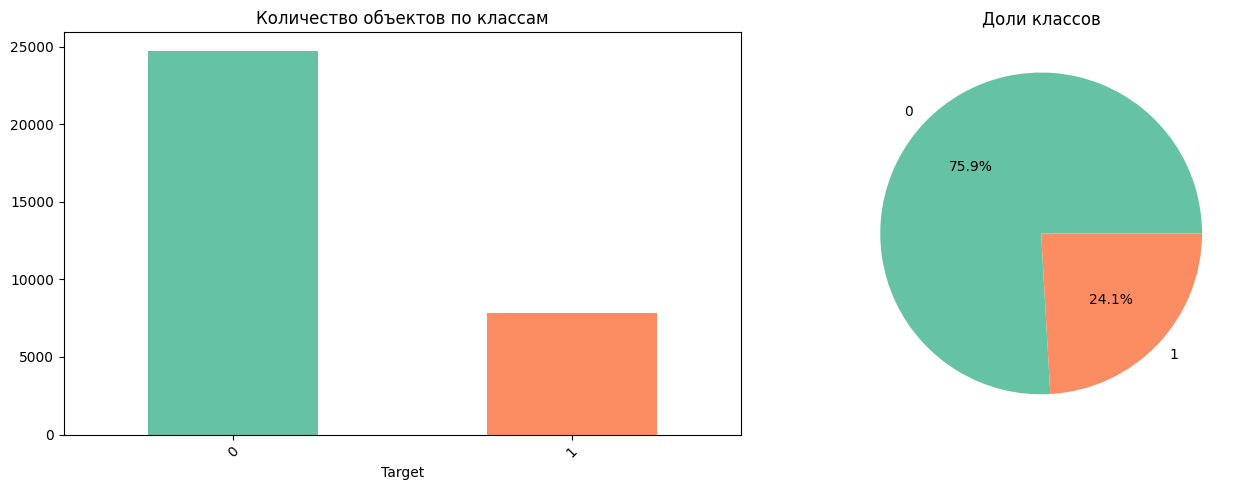

In [50]:
target_col = 'Target'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

adult_data[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

adult_data[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

> В Adult Cencus присутствует дисбаланс классов - целевого класса `~24%`.  
> И это логично, ведь людей, чей доход в год больше 50 тыс. долларов не много.  

### 2.1.8. Распределение числовых и категориальных колонок

#### Числовые колонки

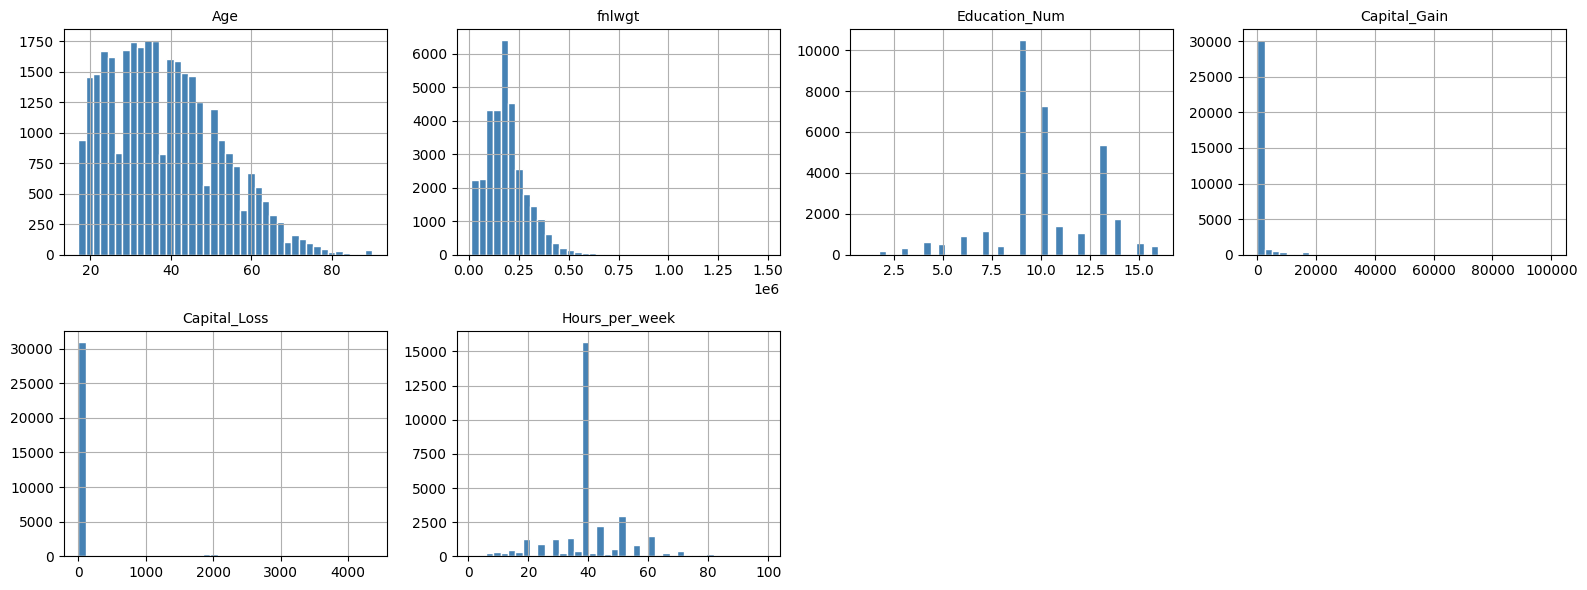

In [51]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    adult_data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Категориальные

In [91]:
for col in cat_cols:
    print("=============\n")
    print(adult_data[col].value_counts().head(5))


Workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Name: count, dtype: int64

Education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64

Martial_Status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64

Occupation
Prof-specialty     4140
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

Relationship
Husband          13193
Not-in-family     8305
Own-child         5068
Unmarried         3446
Wife              1568
Name: count, dtype: int64

Race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

Sex
Male      2179

### 2.1.9. Корреляции признаков

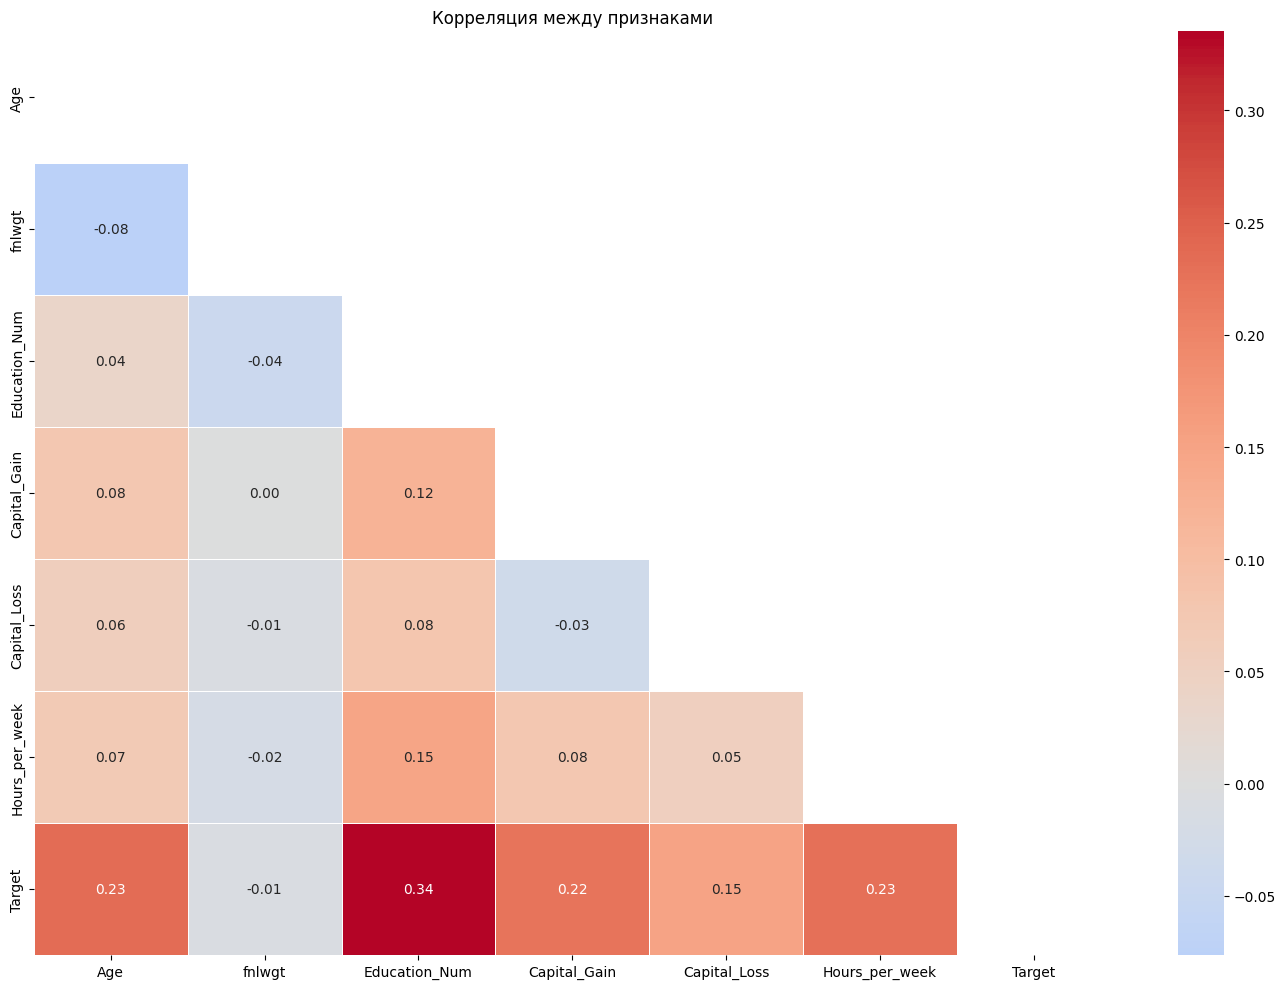

In [55]:
plt.figure(figsize=(14, 10))
corr = adult_data[numeric_cols + ["Target"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Хорошая корреляция с таргетом у признаков `Age`, `Education_Num`, `Capital_Gain`, `Capital_loss`, `Hours_per_week`. Это хорошо, ведь все, за исключением `Hours_per_week`, будут использованы для обучения MLP.  
`FNLWGT` не показал никакой корреляции с целевой переменной, что логично, ведь это служебный признак.

По корреляции с таргетом моэно сделать вывод, что на этих первых признаках задача будет неплохо решаться

## 2.2. Bank Marketing EDA

### 2.2.1. Информация о датасете

Идея датасета:
> Предсказать, согласится ли клиент банка на открытие срочного депозита (term deposit) по результатам маркетинговой кампании.

Банк проводит телемаркетинговую кампанию - обзванивает клиентов и предлагает им открыть депозит. По историческим данным нужно предсказать, кто из клиентов с большей вероятностью согласится, чтобы в будущем оптимизировать бюджет и звонить только тем, кто скорее всего скажет "да".


Бинарная классификация:
- y = yes - клиент открыл депозит
- y = no - клиент отказался

Замечание про `duration`: 
- duration - длительность звонка. И это "нечестный" признак для предсказания
- Если разговор длился долго (duration большое), клиент скорее всего согласился
- Но до звонка мы не знаем, сколько он продлится
- В реальной модели этот признак нужно удалить, иначе точность будет искусственно завышена, да и он будет "на проде" не доступен

### 2.2.2. Начальный анализ колонок, выделение категориальных и числовых признаков

In [61]:
bank_data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [62]:
bank_data.describe(include='O')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [63]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [92]:
target = "y"
numeric_cols = [
    "age", "balance", "day", "duration", "campaign", "pdays", "previous"
]
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

### 2.2.3. Уникальные значения в каждой колонке

In [14]:
print("BANK_DATA")
for col in bank_data.columns:
    print("=============")
    print(col)
    print(bank_data[col].unique())

BANK_DATA
age
[30 33 35 59 36 39 41 43 20 31 40 56 37 25 38 42 44 26 55 67 53 68 32 49
 78 23 52 34 61 45 48 57 54 63 51 29 50 27 60 28 21 58 22 46 24 77 75 47
 70 65 64 62 66 19 81 83 80 71 72 69 79 73 86 74 76 87 84]
job
['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']
marital
['married' 'single' 'divorced']
education
['primary' 'secondary' 'tertiary' 'unknown']
default
['no' 'yes']
balance
[ 1787  4789  1350 ...  -333 -3313  1137]
housing
['no' 'yes']
loan
['no' 'yes']
contact
['cellular' 'unknown' 'telephone']
day
[19 11 16  3  5 23 14  6 17 20 13 30 29 27  7 18 12 21 26 22  2  4 15  8
 28  9  1 10 31 25 24]
month
['oct' 'may' 'apr' 'jun' 'feb' 'aug' 'jan' 'jul' 'nov' 'sep' 'mar' 'dec']
duration
[  79  220  185  199  226  141  341  151   57  313  273  113  328  261
   89  189  239  114  250  148   96  140  109  125  169  182  247  119
  149   74  897   81   40  958  354  150   97  1

### 2.2.3. Дубликаты и пропуски

In [66]:
print("Пропуски: \n", bank_data.isnull().sum().sum())
print("======\nДубликаты ", bank_data.duplicated().sum())

Пропуски: 
 0
Дубликаты  0


### 2.2.4. Таргет и дисбаланс классов

In [68]:
bank_data.y.unique()

array(['no', 'yes'], dtype=object)

In [75]:
bank_data.y.value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [76]:
bank_data.y = bank_data.y.map({'no': 0, 'yes': 1})

In [77]:
bank_data.y.value_counts()

y
0    4000
1     521
Name: count, dtype: int64

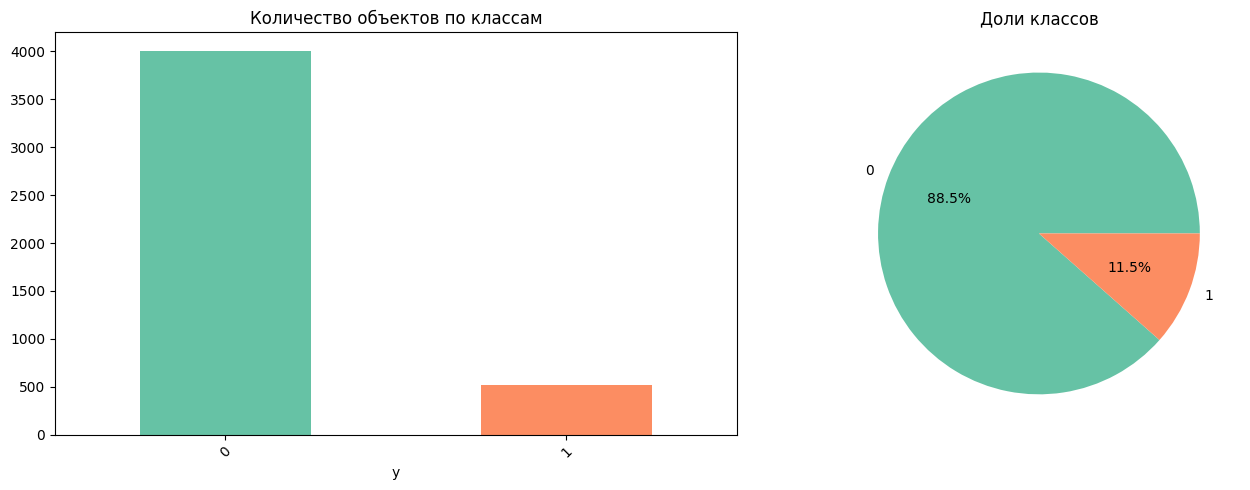

In [79]:
target_col = 'y'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bank_data[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

bank_data[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

> В этом датасете процент класса 1 ~11.5

### 2.2.5. Распределение числовых и категориальных колонок

#### Числовые

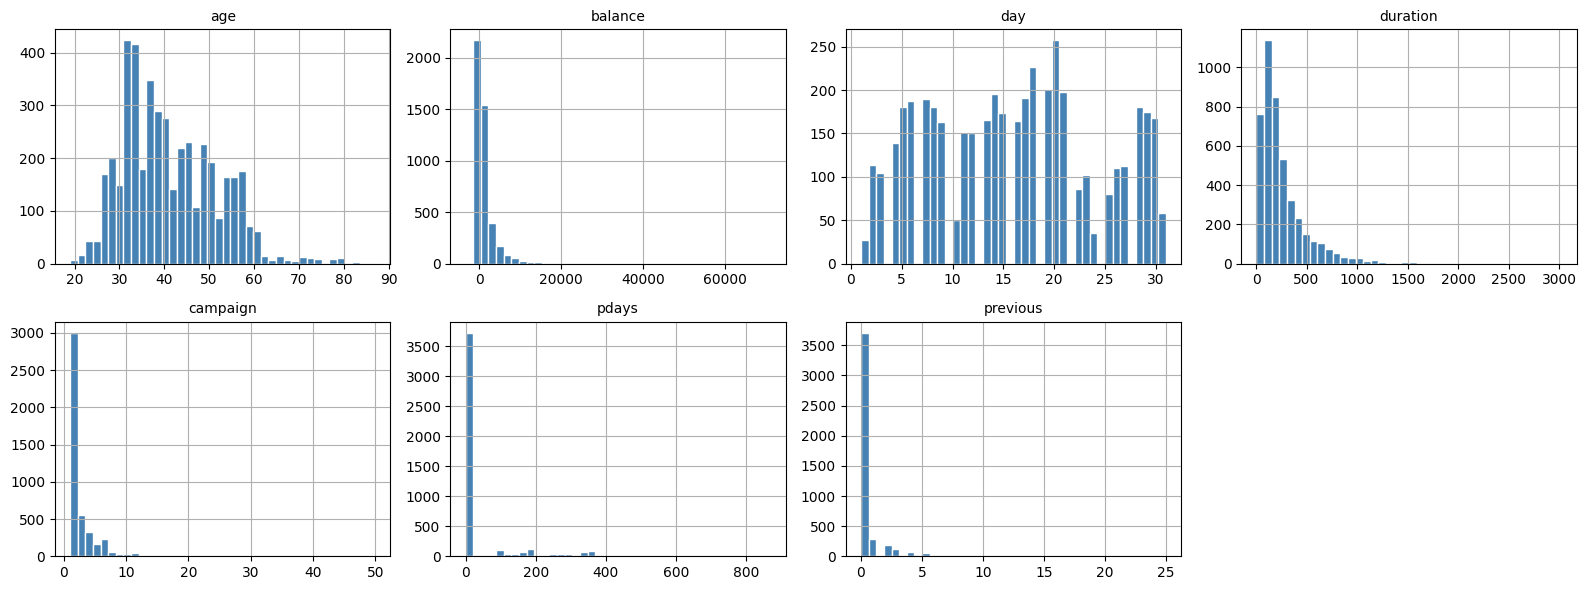

In [80]:
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    bank_data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Категориальные

In [87]:
for col in cat_cols:
    print("=============\n")
    print(bank_data[col].value_counts().head(5))


job
management     969
blue-collar    946
technician     768
admin.         478
services       417
Name: count, dtype: int64

marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64

education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

default
no     4445
yes      76
Name: count, dtype: int64

housing
yes    2559
no     1962
Name: count, dtype: int64

loan
no     3830
yes     691
Name: count, dtype: int64

contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64

month
may    1398
jul     706
aug     633
jun     531
nov     389
Name: count, dtype: int64

poutcome
unknown    3705
failure     490
other       197
success     129
Name: count, dtype: int64


### 2.2.6. Корреляция признаков

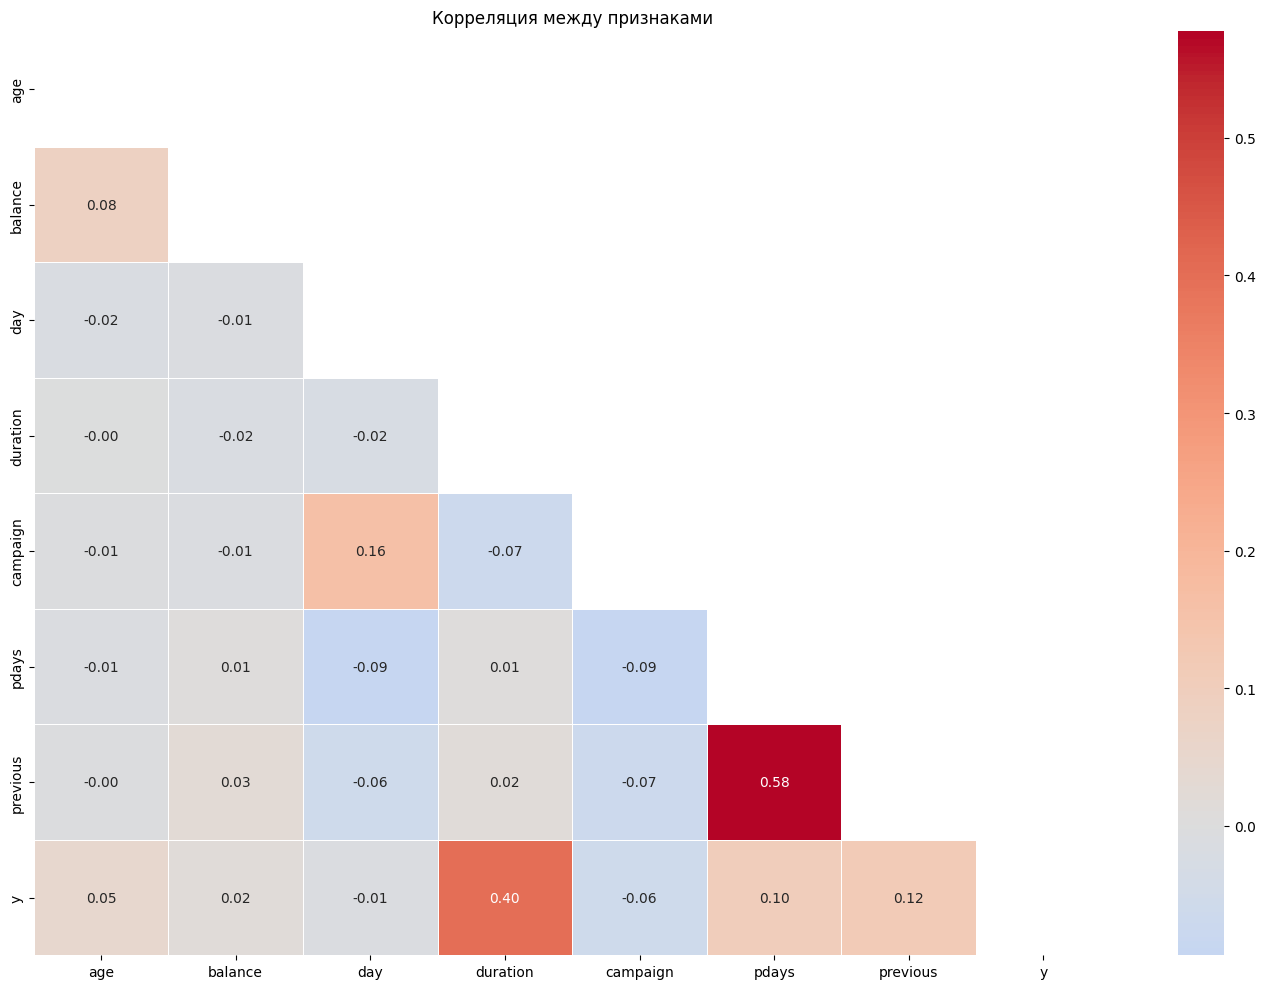

In [93]:
plt.figure(figsize=(14, 10))
corr = bank_data[numeric_cols + ["y"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Можем заметить, что duration по корреляции с таргетом самый большой, т.к. длительность звонка напрямую влияет на результат маркетинговой кампании

## 2.3. Гипотеза по Transfer Learning

### 2.3.1. Постановка гипотезы

> **Гипотеза:** Transfer Learning между Adult Census и Bank Marketing **не даст значимого улучшения** качества по сравнению с обучением с нуля. Результат по целевой метрике будет выше не более чем **на 0.01**.

### 2.3.2. Обоснование гипотезы

#### Разные целевые переменные (разные задачи)

| Датасет | Целевая переменная | Суть задачи |
| :--- | :--- | :--- |
| **Adult Census** | `income > 50K` | Предсказание **уровня дохода** |
| **Bank Marketing** | оформление депозита - yes | Предсказание **поведенческого решения** |

Это **принципиально разные задачи**, хотя обе являются бинарной классификацией. В первом случае модель предсказывает **объективную характеристику** человека (доход), во втором - **субъективное решение** (оформит депозит или нет). Логика принятия решений в этих задачах разная.

#### Геометрическая интерпретация

MLP - это универсальный аппроксиматор, который в процессе обучения строит **гиперплоскость** (решающую поверхность), разделяющую классы в пространстве признаков. При обучении на Adult датасете, эта гиперплоскость «огибает» эти данные, отражая их структуру и связи с таргетом.

Если данные Bank имеют:

- **другое расположение** в пространстве признаков (другие распределения),
- **другие связи** между признаками и таргетом,

то гиперплоскость, выученная на Adult, не сможет быть эффективно адаптирована под Bank. Даже если мы дообучим последние слои модели, они не смогут «перебить» веса первых слоёв, которые уже зафиксировали неправильную для Bank логику. 

## 2.4. Выбор набора признаков для transfer learning 

### 2.4.1. Требования по выбору колонок

Цель - провести Transfer Learning:
> Знания, полученные на одной задаче, помогают решать другую, но похожую задачу

> Поэтому мы не можем взять все признаки из Adult, обучить на них MLP и дообучить его на Bank - часть признаков различается.

Для этого признаки должны быть примерно одинаковыми в обоих датасетах (по количетсву и по значениям). MLP требует фиксированного количества входных нейронов. Использование одинакового набора признаков в обоих датасетах позволяет сохранить единую архитектуру сети.

Что нужно сделать:
- Найти пересечения признаков в Adult и в Bank датасетах.  
- Оставить только общие признаки в обоих датасетах.  
- Удалить всё, что не пересекается.  

### 2.4.2. Выбор колонок для Transfer Learning

На основе EDA для Adult датасета и Bank Marketing датасета были выделены следующие общие колонки:

**Adult данные:**

In [ ]:
adult_cols = [
    'Age',
    'Education',
    "Education_Num",
    'Martial_Status',
    'Occupation',
    'Capital_Gain',
    "Capital_Loss"
]

**Bank Marketing:**

In [ ]:
bank_cols = [
    'age',
    'education',
    'marital',
    'job',
    'balance'
]

> Для переноса знаний между датасетами были отобраны 5 общих признаков, присутствующих в обоих источниках: возраст (Age/age), образование (Education/education), семейное положение (Martial_Status/marital), профессия (Occupation/job) и финансовый показатель ((Capital_Gain - Capital_Loss)/balance). Остальные признаки исключены из-за отсутствия аналога в целевом датасете. Такой подход обеспечивает согласованность данных и корректность эксперимента по Transfer Learning

**Как будут сопоставляться признаки:**
> Bank\[`age`] = Adult\[`Age`]

> В Adult `Education_Num` - это числоавя версия `Education`. Поэтому мы оставим Adult\[`Education_Num`], а Adult\[`Education`] будем использовать для маппинга Bank\[`education`] в числа.

> Bank\[`marital`] = Adult\[`Martial_Status`] с подгоном значений Bank под Adult.

> Bank\[`job`] = Adult\[`Occupation`] с подгоном значений Bank под Adult.

> Bank\[`balance`] = Adult\[`Capital_Gain`] - Adult\[`Capital_Loss`]

# 3. Предварительное обучение на Adult Census (Pre-training)

## 3.1. Введение: Бизнес-задача, метрики и датасет

### 3.1.1. Бизнес-задача

Датасет **Adult Census** решает задачу бинарной классификации - предсказание, превышает ли годовой доход человека 50 000 долларов США.

**Бизнес-контекст:**  
В реальной жизни такая модель может использоваться для:
- Поиска состоятельных клиентов;
- предложения им премиальных финансовых продуктов, инвестиционных услуг и персонального банковского обслуживания

**Ключевое требование:** Нам важно не просто угадать класс, а **отранжировать** всех клиентов по вероятности принадлежности к целевому классу (чтобы, например, предложить специальную скидку первым самым "горячим" клиентам).

### 3.1.2. Целевая метрика

В качестве основной метрики был выбран **AP (average precision)**. Почему?

| Метрика | Проблема | Решение |
| :--- | :--- | :--- |
| **Accuracy** | Классы сильно несбалансированы (~76% `<=50K`, ~24% `>50K`). Accuracy будет вводить в заблуждение (например, модель, предсказывающая всегда `<=50K`, получит 76% accuracy) | **Не используем** |
| **F1-Score** | Хорош для баланса Precision/Recall, но зависит от выбранного порога (0.5) | Используем как **вспомогательную** метрику |
| **Average Precision (AP)** | Стандартная метрика для задач ранжирования. Устойчива к дисбалансу классов | **Основная метрика** |

**Итог:** Основная метрика - **Average Precision (AP)**. Вспомогательная - **F1-Score**.

## 3.2. Обработка данных (Data Preprocessing)

Для обучения MLP на Adult данные возьмем только те колонки, которые:
1. Есть в датасете Bank Marketing
2. Могут быть семантически сопоставлены с признаками из Bank

In [210]:
adult_cols = [
    'Age',
    'Education',
    "Education_Num",
    'Martial_Status',
    'Occupation',
    'Capital_Gain',
    'Capital_Loss',
    'Target'
]

In [211]:
adult_target = "Target"
adult_numeric = [
    "Age",
    "Capital_Gain",
    "Capital_Loss"
]
adult_category = [
    "Education",
    "Martial_Status",
    "Occupation"
]

In [562]:
adult = adult_data.copy(deep=True)
adult = adult[adult_cols]

### 3.2.1. Анализ пропусков

In [563]:
print("Пропуски")
for col in adult.columns:
    print(col, ": ", adult[col].isna().sum())
print("Размер датасета: ", len(adult))

Пропуски
Age :  0
Education :  0
Education_Num :  0
Martial_Status :  0
Occupation :  1843
Capital_Gain :  0
Capital_Loss :  0
Target :  0
Размер датасета:  32561


Пропуски есть только в колонке occupation

In [564]:
adult.Occupation.unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', nan, ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [565]:
adult[adult.Occupation.isna()].describe()

,Age,Education_Num,Capital_Gain,Capital_Loss
count,1843.00000,1843.000000,1843.000000,1843.000000
mean,40.88280,9.253391,604.491047,60.529571
std,20.33635,2.602791,5137.669748,354.030421
min,17.00000,1.000000,0.000000,0.000000
25%,21.00000,9.000000,0.000000,0.000000
50%,35.00000,9.000000,0.000000,0.000000
75%,61.00000,10.000000,0.000000,0.000000
max,90.00000,16.000000,99999.000000,4356.000000


### 3.2.2. Обработка пропусков в Occupation

Добавляем колонку Occupation_Missing - наличие пропусков в колонке occupation. Пропуски же в occupation заполним "Unknown"

In [566]:
adult['Occupation_Missing'] = adult['Occupation'].isna().astype(int)

In [567]:
adult.Occupation_Missing.describe()

count    32561.000000
mean         0.056601
std          0.231083
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Occupation_Missing, dtype: float64

In [568]:
adult['Occupation'] = adult['Occupation'].fillna('Unknown')

In [569]:
adult['Occupation'].isna().sum()

0

Почему так:  
- пропуски могут быть не случайными - возможно, профессия неизвестна, и это само по себе является сигналом. Создавая флаг Occupation_Missing, мы даем модели возможность использовать эту информацию.

### 3.2.3. Очистка значений категориальных признаков

В значениях в начале есть пробелы (например, ' Adm-clerical' вместо 'Adm-clerical'). Удаляем их:

In [570]:
for col in adult_category:
    print(col, adult[col].unique())

Education [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
Martial_Status [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
Occupation [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' 'Unknown'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']


In [571]:
adult['Education'] = adult['Education'].str.strip()
adult['Martial_Status'] = adult['Martial_Status'].str.strip()
adult['Occupation'] = adult['Occupation'].str.strip()

In [572]:
for col in adult_category:
    print(col, adult[col].unique())

Education ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
Martial_Status ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
Occupation ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Unknown'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']


### 3.2.4. Образование: Education и Education_Num

In [573]:
adult[["Education","Education_Num"]].groupby("Education").value_counts()

Education     Education_Num
10th          6                  933
11th          7                 1175
12th          8                  433
1st-4th       2                  168
5th-6th       3                  333
7th-8th       4                  646
9th           5                  514
Assoc-acdm    12                1067
Assoc-voc     11                1382
Bachelors     13                5355
Doctorate     16                 413
HS-grad       9                10501
Masters       14                1723
Preschool     1                   51
Prof-school   15                 576
Some-college  10                7291
Name: count, dtype: int64

Education_Num - это числовая версия Education, поэтому сам Education можно убрать.  
Сохраним эту таблицу для маппинга Bank датасета

In [574]:
education = adult[["Education","Education_Num"]].drop_duplicates().sort_values('Education_Num')

In [575]:
education

,Education,Education_Num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


Вывод: Education - это текстовое представление, Education_Num - его числовая версия. 

### 3.2.5. Создание финансового признака `Financial`

В Bank Marketing есть признак `balance` (среднегодовой баланс). В Adult мы создадим его аналог - `Financial`.

Создаем Financial как разницу доходов и потерь от капитала

In [576]:
adult["Financial"] = adult["Capital_Gain"] - adult["Capital_Loss"]

In [577]:
adult.Financial.describe()

count    32561.000000
mean       990.345014
std       7408.986951
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: Financial, dtype: float64

Есть отрицательные значения (когда Capita_Loss > Capital_Gain)

In [578]:
(adult.Financial < 0).mean()

0.0466509013850926

Отрицательные значения (когда потери > доходы) заменяем на 0.   
Это делает признак сопоставимым с balance (который всегда >= 0).  

In [579]:
adult['Financial'] = adult['Financial'].clip(lower=0)

In [580]:
adult['Financial'].describe()

count    32561.000000
mean      1077.648844
std       7385.292085
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: Financial, dtype: float64

Обоснование:  
`Financial` - это мера финансового благополучия клиента. Большие значения -> клиент с высоким достатком. Это аналогично balance в Bank Marketing.

### 3.2.6. Удаление ненужных колонок

Лишние колонки в ходе преобразования данных нужно убрать

In [581]:
drop_cols = [
    "Capital_Gain",
    "Capital_Loss",
    "Education"
]

In [582]:
print(adult.columns.tolist(), " | ", len(adult.columns))

['Age', 'Education', 'Education_Num', 'Martial_Status', 'Occupation', 'Capital_Gain', 'Capital_Loss', 'Target', 'Occupation_Missing', 'Financial']  |  10


In [583]:
adult = adult.drop(columns=drop_cols)

In [584]:
print(adult.columns.tolist(), " | ", len(adult.columns))

['Age', 'Education_Num', 'Martial_Status', 'Occupation', 'Target', 'Occupation_Missing', 'Financial']  |  7


### 3.2.7. Кодирование категориальных признаков

**Принцип кодирования**:
- `Education_Num` - это порядковый признак (0-16), сотавляем как есть.
- `Martial_Status`, `Occupation` - категориальные признаки, нужно one-hot кодирование.
- `Occupation_Missing` - бинарный, оставить как есть.  

In [585]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 32561 non-null  int64 
 1   Education_Num       32561 non-null  int64 
 2   Martial_Status      32561 non-null  object
 3   Occupation          32561 non-null  object
 4   Target              32561 non-null  object
 5   Occupation_Missing  32561 non-null  int32 
 6   Financial           32561 non-null  int64 
dtypes: int32(1), int64(3), object(3)
memory usage: 1.6+ MB


In [586]:
from sklearn.preprocessing import OneHotEncoder

In [587]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [588]:
adult_cat = adult[['Martial_Status', 'Occupation']]
encoder.fit(adult_cat)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

Преобразуем Adult

In [589]:
adult_encoded = encoder.transform(adult_cat)

In [590]:
adult_encoded_df = pd.DataFrame(
    adult_encoded,
    columns=encoder.get_feature_names_out(['Martial_Status', 'Occupation']),
    index=adult.index
)

Добавляем и удаляем исходные колонки

In [591]:
adult = pd.concat([adult, adult_encoded_df], axis=1)
adult = adult.drop(columns=['Martial_Status', 'Occupation'])

In [592]:
adult.head()

,Age,Education_Num,Target,Occupation_Missing,Financial,Martial_Status_Divorced,Martial_Status_Married-AF-spouse,Martial_Status_Married-civ-spouse,Martial_Status_Married-spouse-absent,Martial_Status_Never-married,...,Occupation_Handlers-cleaners,Occupation_Machine-op-inspct,Occupation_Other-service,Occupation_Priv-house-serv,Occupation_Prof-specialty,Occupation_Protective-serv,Occupation_Sales,Occupation_Tech-support,Occupation_Transport-moving,Occupation_Unknown
0,39,13,<=50K,0,2174,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50,13,<=50K,0,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38,9,<=50K,0,0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,53,7,<=50K,0,0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,28,13,<=50K,0,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [593]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   32561 non-null  int64  
 1   Education_Num                         32561 non-null  int64  
 2   Target                                32561 non-null  object 
 3   Occupation_Missing                    32561 non-null  int32  
 4   Financial                             32561 non-null  int64  
 5   Martial_Status_Divorced               32561 non-null  float64
 6   Martial_Status_Married-AF-spouse      32561 non-null  float64
 7   Martial_Status_Married-civ-spouse     32561 non-null  float64
 8   Martial_Status_Married-spouse-absent  32561 non-null  float64
 9   Martial_Status_Never-married          32561 non-null  float64
 10  Martial_Status_Separated              32561 non-null  float64
 11  Martial_Status_

**Важно**: Этот encoder нужно сохранить и применить к Bank Marketing для обеспечения одинаковых колонок

### 3.2.8. Логарифмирование `Financial`

In [1288]:
adult_numeric = ["Age", "Education_Num", "Financial"]

In [597]:
adult[adult_numeric].head()

,Age,Education_Num,Financial
0,39,13,2174
1,50,13,0
2,38,9,0
3,53,7,0
4,28,13,0


Логарифмируем Financial

In [598]:
adult['Financial_log'] = np.log1p(adult['Financial'])

In [599]:
adult = adult.drop(columns=["Financial"])

Почему логарифмируем Financial?  
Распределение сильно скошено вправо (много нулей и редкие большие значения). Логарифм будет сжимать выбросы и улучшать обучение MLP.  

### 3.2.9. Преобразование целевой переменной

Проверяем текущие значения

In [604]:
adult.Target.unique()

array([' <=50K', ' >50K'], dtype=object)

In [605]:
adult.Target.value_counts()

Target
<=50K    24720
>50K      7841
Name: count, dtype: int64

Переводим >50K как 1, а <=50K как 0

In [606]:
adult.Target = adult.Target.map({' <=50K': 0, ' >50K': 1})

Проверяем после преобразования

In [607]:
adult.Target.value_counts()

Target
0    24720
1     7841
Name: count, dtype: int64

## 3.3. Подготовка данных для обучения сети

### 3.3.1. Зависимости и установка SEED для воспроизводимости

In [611]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [612]:
import random

In [614]:
SEED = 42
random.seed(SEED)

# NumPy random
np.random.seed(SEED)
# PyTorch random (CPU)
torch.manual_seed(SEED)
# PyTorch random (GPU)
if torch.cuda.is_available():
  torch.cuda.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)

In [613]:
BATCH_SIZE = 64

### 3.3.2. Разделение колонок на признаки и таргет

In [608]:
print("Число объектов: ", len(adult))
print("Число колонок: ", len(adult.columns))

Число объектов:  32561
Число колонок:  27


In [609]:
columns = adult.columns.tolist()

In [1300]:
X_adult, y_adult = adult.drop(columns=["Target"]), adult.Target.astype(np.float32).values

### 3.3.3. Разделение на train/val

In [1287]:
from sklearn.preprocessing import StandardScaler

In [1297]:
X_train, X_val, y_train, y_val = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=SEED, stratify=y_adult
)

### 3.3.4. Стандартизация Train и Val выборки

In [1289]:
scaler = StandardScaler()

In [1290]:
adult_numeric = ["Age", "Education_Num", "Financial_log"]

Собираем статистики на train

In [1298]:
X_train[adult_numeric] = scaler.fit_transform(X_train[adult_numeric])

Применяем на val

In [1299]:
X_val[adult_numeric] = scaler.transform(X_val[adult_numeric])

Переводим в numpy массив для последующего перевода в torch tensor

In [1301]:
X_train = X_train.astype(np.float32).values

In [1302]:
X_val = X_val.astype(np.float32).values

### 3.3.5. Создание DataLoader-ов

Создаем train dataset и data loader

In [616]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

In [617]:
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
iter_train = iter(train_loader)
next(iter_train)

Создаем val датасет и даталоадер

In [619]:
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

In [620]:
val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
iter_val = iter(val_loader)
next(iter_train)

In [622]:
del iter_val, iter_train

## 3.4. Утилиты для обучения

In [623]:
import torch.optim as optim

In [624]:
from sklearn.metrics import precision_score, recall_score, average_precision_score, f1_score, accuracy_score

In [625]:
from tqdm import tqdm

In [626]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [759]:
def train_model(model, 
                epochs=10, 
                lr=1e-3, 
                optimizer_cls=optim.Adam, 
                weight_decay=0, 
                scheduler_cls=None, 
                write_metrics_after_every_epoch=True,
                return_best_params=False,
                train_loader=None,
                val_loader=None,
                criterion=None):
    
    if train_loader is None or val_loader is None:
        raise ValueError("train_loader и val_loader должны быть переданы в функцию")
    
    model = model.to(device)
    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = scheduler_cls(optimizer) if scheduler_cls else None
    criterion = nn.BCELoss() if criterion is None else criterion
    
    # История обучения
    history = {"train_loss": [], "train_f1": [], 
              "val_f1": [], "val_avg_precision": []}
    
    # Переменные для хранения лучшей метрики и параметров в ходе обучения
    best_parameters = None
    best_metric = -float('inf')
    best_state_dict = None

    for epoch in range(epochs):
        model.train()
        total_loss, total = 0, 0
        y_true_train, y_pred_train = [], []

        for X, y in tqdm(train_loader, 
                         desc=f"Epoch {epoch+1}/{epochs}", 
                         leave=False):
            
            X, y = X.to(device), y.to(device)
            
            # Forward pass
            out = model(X)
            loss = criterion(out, y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # preds
            total_loss += loss.item() * X.size(0)
            total += X.size(0)
            pred = (out > 0.5).float()
            
            y_true_train.extend(y.cpu().numpy())
            y_pred_train.extend(pred.cpu().numpy())
            
        if scheduler:
            scheduler.step()

        # calculate metrics
        metrics = evaluate(model, val_loader)
        
        # train f1
        y_true_train = np.array(y_true_train).flatten()
        y_pred_train = np.array(y_pred_train).flatten()
        train_f1 = f1_score(y_true_train, y_pred_train)

        # metrics
        history["train_loss"].append(total_loss / total)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(metrics["f1"])
        history["val_avg_precision"].append(metrics["avg_precision"])

        # сохранение весов лучшей модели
        current_metric = metrics["avg_precision"]
        if current_metric > best_metric:
            best_metric = current_metric
            best_parameters = {k: v.cpu().clone() for k, v in model.state_dict().items()} # копия параметров

        if write_metrics_after_every_epoch:
            tqdm.write(f"Epoch {epoch+1}/{epochs} | "
                  f"Loss: {total_loss/total:.4f} | "
                  f"Train F1: {train_f1:.4f} | "
                  f"Val F1: {metrics['f1']:.4f} | "
                  f"Val AP: {metrics['avg_precision']:.4f}")

    n_params = sum(p.numel() for p in model.parameters())
    print(f"{model.__class__.__name__:20s} | {n_params:>8,} | "
         f"train_f1: {history["train_f1"][-1]:.4f} | val_f1: {history["val_f1"][-1]:.4f}")
    return history, best_parameters

def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            prob = model(X)
            pred = (prob > 0.5).float()
            
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
            
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    y_prob = np.array(y_prob).flatten()

    return {
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'avg_precision': average_precision_score(y_true, y_prob)
    }

In [628]:
def plot_history(history, title=" "):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Train Loss
    axes[0, 0].plot(history["train_loss"])
    axes[0, 0].set_title("Train Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].grid(True, alpha=0.3)
    
    # Train F1
    axes[0, 1].plot(history["train_f1"])
    axes[0, 1].set_title("Train F1")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].grid(True, alpha=0.3)
    
    # Val F1
    axes[1, 0].plot(history["val_f1"])
    axes[1, 0].set_title("Validation F1")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].grid(True, alpha=0.3)
    
    # Val Average Precision
    axes[1, 1].plot(history["val_avg_precision"])
    axes[1, 1].set_title("Validation Average Precision")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].grid(True, alpha=0.3)
    
    if title:
        fig.suptitle(title, fontweight="bold", fontsize=14)
    
    plt.tight_layout()
    plt.show()

Краткое описание функций:
- `train_model` - основной цикл обучения: forward, backward, логирование, сохранение лучших весов
- `evaluate` - вычисление F1 и AP на валидации/тесте
- `plot_history` - построение графиков Loss, F1 и AP по эпохам

## 3.5. Класс MLP

Количество признаков

In [629]:
in_dim = X_train_t.shape[-1]

In [630]:
in_dim

26

In [631]:
import torch.nn as nn

In [632]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, activation=nn.ReLU, dropout=0.0, use_bn=False):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 3.6. Поиск оптимальных гиперпараметров

### 3.6.1. Фиксированные параметры

In [633]:
from functools import partial
from torch.optim.lr_scheduler import CosineAnnealingLR

In [634]:
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
OPTIMIZER = optim.Adam
SCHEDULER = partial(CosineAnnealingLR, T_max=EPOCHS)

### 3.6.2. Сетка параметров

In [635]:
param_configs = [
    [64, 32],
    [128, 64],
    [256, 128, 64],
    [64, 64, 64],
    [512, 256, 128],
    [128, 64, 32],
]

use_batchnorm_configs = [False, True]

dropout_configs = [0.0, 0.1, 0.3]

activation_configs = [
    nn.ReLU,
    nn.SELU
]

### 3.6.3. Число комбинаций (и обучаемых моделей)

In [636]:
total_configs = (
    len(param_configs) * 
    len(activation_configs) * 
    len(dropout_configs) * 
    len(use_batchnorm_configs)
)
total_configs

72

In [637]:
histories = []

In [638]:
model_id = 0

### 3.6.4. **Запуск поиска**

In [639]:
for params in param_configs:
    for activation in activation_configs:
        for dropout in dropout_configs:
            for use_bn in use_batchnorm_configs:
                print(f"=========")
                print(f"Model {model_id+1}/{total_configs}")
                print(f"Config: hidden={params}, act={activation.__name__}, "
                      f"dropout={dropout}, bn={use_bn}")
                
                mlp = MLP(
                    input_dim=in_dim,
                    hidden_sizes=params,
                    activation=activation,
                    dropout=dropout,
                    use_bn=use_bn
                )
                
                history, _ = train_model(
                    mlp,
                    epochs=EPOCHS,
                    lr=LR,
                    weight_decay=WEIGHT_DECAY,
                    optimizer_cls=OPTIMIZER,
                    scheduler_cls=SCHEDULER,
                    write_metrics_after_every_epoch=False
                )
                
                best_ap = max(history['val_avg_precision'])
                best_f1 = max(history['val_f1'])

                print(f"BEST: AP={best_ap:.4f}, F1={best_f1:.4f}")

                histories.append({
                    'config': {
                        'hidden_sizes': params,
                        'activation': activation.__name__,
                        'dropout': dropout,
                        'use_bn': use_bn,
                        'lr': LR,
                        'weight_decay': WEIGHT_DECAY,
                        'optimizer': 'Adam',
                        'scheduler': 'CosineAnnealingLR'
                    },
                    'history': history,
                    'best_ap': best_ap,
                    'best_f1': best_f1
                })

                model_id += 1

Model 1/72
Config: hidden=[64, 32], act=ReLU, dropout=0.0, bn=False


MLP                  |    3,841 | train_f1: 0.6674 | val_f1: 0.6703
BEST: AP=0.7769, F1=0.6748
Model 2/72
Config: hidden=[64, 32], act=ReLU, dropout=0.0, bn=True


MLP                  |    4,033 | train_f1: 0.6574 | val_f1: 0.6577
BEST: AP=0.7656, F1=0.6630
Model 3/72
Config: hidden=[64, 32], act=ReLU, dropout=0.1, bn=False


MLP                  |    3,841 | train_f1: 0.6599 | val_f1: 0.6655
BEST: AP=0.7781, F1=0.6768
Model 4/72
Config: hidden=[64, 32], act=ReLU, dropout=0.1, bn=True


MLP                  |    4,033 | train_f1: 0.6435 | val_f1: 0.6594
BEST: AP=0.7566, F1=0.6722
Model 5/72
Config: hidden=[64, 32], act=ReLU, dropout=0.3, bn=False


MLP                  |    3,841 | train_f1: 0.6521 | val_f1: 0.6493
BEST: AP=0.7577, F1=0.6597
Model 6/72
Config: hidden=[64, 32], act=ReLU, dropout=0.3, bn=True


MLP                  |    4,033 | train_f1: 0.6382 | val_f1: 0.6468
BEST: AP=0.7493, F1=0.6658
Model 7/72
Config: hidden=[64, 32], act=SELU, dropout=0.0, bn=False


MLP                  |    3,841 | train_f1: 0.6547 | val_f1: 0.6599
BEST: AP=0.7642, F1=0.6680
Model 8/72
Config: hidden=[64, 32], act=SELU, dropout=0.0, bn=True


MLP                  |    4,033 | train_f1: 0.6493 | val_f1: 0.6667
BEST: AP=0.7690, F1=0.6693
Model 9/72
Config: hidden=[64, 32], act=SELU, dropout=0.1, bn=False


MLP                  |    3,841 | train_f1: 0.6383 | val_f1: 0.6475
BEST: AP=0.7475, F1=0.6543
Model 10/72
Config: hidden=[64, 32], act=SELU, dropout=0.1, bn=True


MLP                  |    4,033 | train_f1: 0.6372 | val_f1: 0.6466
BEST: AP=0.7528, F1=0.6568
Model 11/72
Config: hidden=[64, 32], act=SELU, dropout=0.3, bn=False


MLP                  |    3,841 | train_f1: 0.6241 | val_f1: 0.6392
BEST: AP=0.7349, F1=0.6522
Model 12/72
Config: hidden=[64, 32], act=SELU, dropout=0.3, bn=True


MLP                  |    4,033 | train_f1: 0.6285 | val_f1: 0.6512
BEST: AP=0.7449, F1=0.6656
Model 13/72
Config: hidden=[128, 64], act=ReLU, dropout=0.0, bn=False


MLP                  |   11,777 | train_f1: 0.6670 | val_f1: 0.6678
BEST: AP=0.7797, F1=0.6790
Model 14/72
Config: hidden=[128, 64], act=ReLU, dropout=0.0, bn=True


MLP                  |   12,161 | train_f1: 0.6594 | val_f1: 0.6626
BEST: AP=0.7681, F1=0.6747
Model 15/72
Config: hidden=[128, 64], act=ReLU, dropout=0.1, bn=False


MLP                  |   11,777 | train_f1: 0.6631 | val_f1: 0.6634
BEST: AP=0.7798, F1=0.6772
Model 16/72
Config: hidden=[128, 64], act=ReLU, dropout=0.1, bn=True


MLP                  |   12,161 | train_f1: 0.6521 | val_f1: 0.6614
BEST: AP=0.7650, F1=0.6644
Model 17/72
Config: hidden=[128, 64], act=ReLU, dropout=0.3, bn=False


MLP                  |   11,777 | train_f1: 0.6582 | val_f1: 0.6582
BEST: AP=0.7797, F1=0.6671
Model 18/72
Config: hidden=[128, 64], act=ReLU, dropout=0.3, bn=True


MLP                  |   12,161 | train_f1: 0.6400 | val_f1: 0.6490
BEST: AP=0.7519, F1=0.6627
Model 19/72
Config: hidden=[128, 64], act=SELU, dropout=0.0, bn=False


MLP                  |   11,777 | train_f1: 0.6600 | val_f1: 0.6616
BEST: AP=0.7676, F1=0.6762
Model 20/72
Config: hidden=[128, 64], act=SELU, dropout=0.0, bn=True


MLP                  |   12,161 | train_f1: 0.6508 | val_f1: 0.6613
BEST: AP=0.7737, F1=0.6802
Model 21/72
Config: hidden=[128, 64], act=SELU, dropout=0.1, bn=False


MLP                  |   11,777 | train_f1: 0.6472 | val_f1: 0.6555
BEST: AP=0.7565, F1=0.6598
Model 22/72
Config: hidden=[128, 64], act=SELU, dropout=0.1, bn=True


MLP                  |   12,161 | train_f1: 0.6430 | val_f1: 0.6498
BEST: AP=0.7592, F1=0.6647
Model 23/72
Config: hidden=[128, 64], act=SELU, dropout=0.3, bn=False


MLP                  |   11,777 | train_f1: 0.6351 | val_f1: 0.6462
BEST: AP=0.7449, F1=0.6561
Model 24/72
Config: hidden=[128, 64], act=SELU, dropout=0.3, bn=True


MLP                  |   12,161 | train_f1: 0.6353 | val_f1: 0.6492
BEST: AP=0.7474, F1=0.6638
Model 25/72
Config: hidden=[256, 128, 64], act=ReLU, dropout=0.0, bn=False


MLP                  |   48,129 | train_f1: 0.6717 | val_f1: 0.6653
BEST: AP=0.7806, F1=0.6882
Model 26/72
Config: hidden=[256, 128, 64], act=ReLU, dropout=0.0, bn=True


MLP                  |   49,025 | train_f1: 0.6578 | val_f1: 0.6644
BEST: AP=0.7769, F1=0.6703
Model 27/72
Config: hidden=[256, 128, 64], act=ReLU, dropout=0.1, bn=False


MLP                  |   48,129 | train_f1: 0.6700 | val_f1: 0.6671
BEST: AP=0.7812, F1=0.6927
Model 28/72
Config: hidden=[256, 128, 64], act=ReLU, dropout=0.1, bn=True


MLP                  |   49,025 | train_f1: 0.6501 | val_f1: 0.6642
BEST: AP=0.7725, F1=0.6682
Model 29/72
Config: hidden=[256, 128, 64], act=ReLU, dropout=0.3, bn=False


MLP                  |   48,129 | train_f1: 0.6632 | val_f1: 0.6634
BEST: AP=0.7820, F1=0.6699
Model 30/72
Config: hidden=[256, 128, 64], act=ReLU, dropout=0.3, bn=True


MLP                  |   49,025 | train_f1: 0.6480 | val_f1: 0.6558
BEST: AP=0.7572, F1=0.6606
Model 31/72
Config: hidden=[256, 128, 64], act=SELU, dropout=0.0, bn=False


MLP                  |   48,129 | train_f1: 0.6638 | val_f1: 0.6683
BEST: AP=0.7817, F1=0.6779
Model 32/72
Config: hidden=[256, 128, 64], act=SELU, dropout=0.0, bn=True


MLP                  |   49,025 | train_f1: 0.6574 | val_f1: 0.6701
BEST: AP=0.7814, F1=0.6834
Model 33/72
Config: hidden=[256, 128, 64], act=SELU, dropout=0.1, bn=False


MLP                  |   48,129 | train_f1: 0.6544 | val_f1: 0.6597
BEST: AP=0.7674, F1=0.6701
Model 34/72
Config: hidden=[256, 128, 64], act=SELU, dropout=0.1, bn=True


MLP                  |   49,025 | train_f1: 0.6439 | val_f1: 0.6565
BEST: AP=0.7683, F1=0.6741
Model 35/72
Config: hidden=[256, 128, 64], act=SELU, dropout=0.3, bn=False


MLP                  |   48,129 | train_f1: 0.6436 | val_f1: 0.6505
BEST: AP=0.7512, F1=0.6622
Model 36/72
Config: hidden=[256, 128, 64], act=SELU, dropout=0.3, bn=True


MLP                  |   49,025 | train_f1: 0.6325 | val_f1: 0.6361
BEST: AP=0.7488, F1=0.6648
Model 37/72
Config: hidden=[64, 64, 64], act=ReLU, dropout=0.0, bn=False


MLP                  |   10,113 | train_f1: 0.6687 | val_f1: 0.6641
BEST: AP=0.7803, F1=0.6790
Model 38/72
Config: hidden=[64, 64, 64], act=ReLU, dropout=0.0, bn=True


MLP                  |   10,497 | train_f1: 0.6584 | val_f1: 0.6634
BEST: AP=0.7753, F1=0.6685
Model 39/72
Config: hidden=[64, 64, 64], act=ReLU, dropout=0.1, bn=False


MLP                  |   10,113 | train_f1: 0.6636 | val_f1: 0.6636
BEST: AP=0.7806, F1=0.6755
Model 40/72
Config: hidden=[64, 64, 64], act=ReLU, dropout=0.1, bn=True


MLP                  |   10,497 | train_f1: 0.6491 | val_f1: 0.6628
BEST: AP=0.7610, F1=0.6762
Model 41/72
Config: hidden=[64, 64, 64], act=ReLU, dropout=0.3, bn=False


MLP                  |   10,113 | train_f1: 0.6581 | val_f1: 0.6516
BEST: AP=0.7771, F1=0.6726
Model 42/72
Config: hidden=[64, 64, 64], act=ReLU, dropout=0.3, bn=True


MLP                  |   10,497 | train_f1: 0.6345 | val_f1: 0.6438
BEST: AP=0.7485, F1=0.6637
Model 43/72
Config: hidden=[64, 64, 64], act=SELU, dropout=0.0, bn=False


MLP                  |   10,113 | train_f1: 0.6625 | val_f1: 0.6662
BEST: AP=0.7807, F1=0.6757
Model 44/72
Config: hidden=[64, 64, 64], act=SELU, dropout=0.0, bn=True


MLP                  |   10,497 | train_f1: 0.6569 | val_f1: 0.6584
BEST: AP=0.7809, F1=0.6953
Model 45/72
Config: hidden=[64, 64, 64], act=SELU, dropout=0.1, bn=False


MLP                  |   10,113 | train_f1: 0.6421 | val_f1: 0.6518
BEST: AP=0.7526, F1=0.6669
Model 46/72
Config: hidden=[64, 64, 64], act=SELU, dropout=0.1, bn=True


MLP                  |   10,497 | train_f1: 0.6372 | val_f1: 0.6535
BEST: AP=0.7558, F1=0.6669
Model 47/72
Config: hidden=[64, 64, 64], act=SELU, dropout=0.3, bn=False


MLP                  |   10,113 | train_f1: 0.6316 | val_f1: 0.6433
BEST: AP=0.7420, F1=0.6593
Model 48/72
Config: hidden=[64, 64, 64], act=SELU, dropout=0.3, bn=True


MLP                  |   10,497 | train_f1: 0.6292 | val_f1: 0.6508
BEST: AP=0.7430, F1=0.6667
Model 49/72
Config: hidden=[512, 256, 128], act=ReLU, dropout=0.0, bn=False


MLP                  |  178,177 | train_f1: 0.6711 | val_f1: 0.6650
BEST: AP=0.7812, F1=0.6821
Model 50/72
Config: hidden=[512, 256, 128], act=ReLU, dropout=0.0, bn=True


MLP                  |  179,969 | train_f1: 0.6623 | val_f1: 0.6709
BEST: AP=0.7783, F1=0.6748
Model 51/72
Config: hidden=[512, 256, 128], act=ReLU, dropout=0.1, bn=False


MLP                  |  178,177 | train_f1: 0.6690 | val_f1: 0.6634
BEST: AP=0.7811, F1=0.6782
Model 52/72
Config: hidden=[512, 256, 128], act=ReLU, dropout=0.1, bn=True


MLP                  |  179,969 | train_f1: 0.6548 | val_f1: 0.6669
BEST: AP=0.7742, F1=0.6775
Model 53/72
Config: hidden=[512, 256, 128], act=ReLU, dropout=0.3, bn=False


MLP                  |  178,177 | train_f1: 0.6642 | val_f1: 0.6646
BEST: AP=0.7819, F1=0.6862
Model 54/72
Config: hidden=[512, 256, 128], act=ReLU, dropout=0.3, bn=True


MLP                  |  179,969 | train_f1: 0.6442 | val_f1: 0.6644
BEST: AP=0.7648, F1=0.6644
Model 55/72
Config: hidden=[512, 256, 128], act=SELU, dropout=0.0, bn=False


MLP                  |  178,177 | train_f1: 0.6659 | val_f1: 0.6678
BEST: AP=0.7826, F1=0.6825
Model 56/72
Config: hidden=[512, 256, 128], act=SELU, dropout=0.0, bn=True


MLP                  |  179,969 | train_f1: 0.6561 | val_f1: 0.6615
BEST: AP=0.7802, F1=0.6802
Model 57/72
Config: hidden=[512, 256, 128], act=SELU, dropout=0.1, bn=False


MLP                  |  178,177 | train_f1: 0.6591 | val_f1: 0.6641
BEST: AP=0.7812, F1=0.6807
Model 58/72
Config: hidden=[512, 256, 128], act=SELU, dropout=0.1, bn=True


MLP                  |  179,969 | train_f1: 0.6498 | val_f1: 0.6600
BEST: AP=0.7692, F1=0.6761
Model 59/72
Config: hidden=[512, 256, 128], act=SELU, dropout=0.3, bn=False


MLP                  |  178,177 | train_f1: 0.6575 | val_f1: 0.6685
BEST: AP=0.7805, F1=0.6802
Model 60/72
Config: hidden=[512, 256, 128], act=SELU, dropout=0.3, bn=True


MLP                  |  179,969 | train_f1: 0.6329 | val_f1: 0.6497
BEST: AP=0.7489, F1=0.6595
Model 61/72
Config: hidden=[128, 64, 32], act=ReLU, dropout=0.0, bn=False


MLP                  |   13,825 | train_f1: 0.6692 | val_f1: 0.6676
BEST: AP=0.7800, F1=0.6784
Model 62/72
Config: hidden=[128, 64, 32], act=ReLU, dropout=0.0, bn=True


MLP                  |   14,273 | train_f1: 0.6630 | val_f1: 0.6651
BEST: AP=0.7764, F1=0.6696
Model 63/72
Config: hidden=[128, 64, 32], act=ReLU, dropout=0.1, bn=False


MLP                  |   13,825 | train_f1: 0.6613 | val_f1: 0.6620
BEST: AP=0.7812, F1=0.6775
Model 64/72
Config: hidden=[128, 64, 32], act=ReLU, dropout=0.1, bn=True


MLP                  |   14,273 | train_f1: 0.6495 | val_f1: 0.6576
BEST: AP=0.7654, F1=0.6651
Model 65/72
Config: hidden=[128, 64, 32], act=ReLU, dropout=0.3, bn=False


MLP                  |   13,825 | train_f1: 0.6580 | val_f1: 0.6605
BEST: AP=0.7802, F1=0.6696
Model 66/72
Config: hidden=[128, 64, 32], act=ReLU, dropout=0.3, bn=True


MLP                  |   14,273 | train_f1: 0.6355 | val_f1: 0.6436
BEST: AP=0.7521, F1=0.6673
Model 67/72
Config: hidden=[128, 64, 32], act=SELU, dropout=0.0, bn=False


MLP                  |   13,825 | train_f1: 0.6636 | val_f1: 0.6669
BEST: AP=0.7820, F1=0.6808
Model 68/72
Config: hidden=[128, 64, 32], act=SELU, dropout=0.0, bn=True


MLP                  |   14,273 | train_f1: 0.6554 | val_f1: 0.6600
BEST: AP=0.7815, F1=0.6816
Model 69/72
Config: hidden=[128, 64, 32], act=SELU, dropout=0.1, bn=False


MLP                  |   13,825 | train_f1: 0.6443 | val_f1: 0.6484
BEST: AP=0.7530, F1=0.6727
Model 70/72
Config: hidden=[128, 64, 32], act=SELU, dropout=0.1, bn=True


MLP                  |   14,273 | train_f1: 0.6428 | val_f1: 0.6443
BEST: AP=0.7571, F1=0.6647
Model 71/72
Config: hidden=[128, 64, 32], act=SELU, dropout=0.3, bn=False


MLP                  |   13,825 | train_f1: 0.6391 | val_f1: 0.6502
BEST: AP=0.7449, F1=0.6627
Model 72/72
Config: hidden=[128, 64, 32], act=SELU, dropout=0.3, bn=True


MLP                  |   14,273 | train_f1: 0.6343 | val_f1: 0.6491
BEST: AP=0.7460, F1=0.6669


### 3.6.5. Результаты поиска

Так как нам важен AP, нужно отсортировать вывод по AP

In [644]:
sorted_results = sorted(histories, key=lambda x: x['best_ap'], reverse=True)

In [645]:
print("Первые 10 лучших параметров:")
for i, res in enumerate(sorted_results[:10]):
    print(f"\n{i+1}. AP={res['best_ap']:.4f}, F1={res['best_f1']:.4f}")
    print(f"Config: {res['config']}")
    print("--------")

Первые 10 лучших параметров:

1. AP=0.7826, F1=0.6825
Config: {'hidden_sizes': [512, 256, 128], 'activation': 'SELU', 'dropout': 0.0, 'use_bn': False, 'lr': 0.001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR'}
--------

2. AP=0.7820, F1=0.6808
Config: {'hidden_sizes': [128, 64, 32], 'activation': 'SELU', 'dropout': 0.0, 'use_bn': False, 'lr': 0.001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR'}
--------

3. AP=0.7820, F1=0.6699
Config: {'hidden_sizes': [256, 128, 64], 'activation': 'ReLU', 'dropout': 0.3, 'use_bn': False, 'lr': 0.001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR'}
--------

4. AP=0.7819, F1=0.6862
Config: {'hidden_sizes': [512, 256, 128], 'activation': 'ReLU', 'dropout': 0.3, 'use_bn': False, 'lr': 0.001, 'weight_decay': 0.0001, 'optimizer': 'Adam', 'scheduler': 'CosineAnnealingLR'}
--------

5. AP=0.7817, F1=0.6779
Config: {'hidden_sizes': [256, 128, 64], 'activation': 'S

> В результате поиска по гиперпараметрам лучшая конфигурация показала AP=0.7826 и F1=0.6825. Наиболее эффективной оказалась архитектура 512 -> 256 -> 128, лучшая активация - SELU.

Ключевые выводы:
- лучшая архитектура: \[512, 256, 128] с активацией SELU
- BatchNorm ухудшает качество: 8 из 10 лучших моделей без BN
- dropout не обязателен: 5 из 10 лучших моделей с dropout=0.0
- SELU vs ReLU: Равное количество в топ-10 (5 и 5)

### 3.6.6. Лучшая конфигурация

In [646]:
#best_config = {'hidden_sizes': [512, 256, 128], 
#               'activation': 'SELU', 
#               'dropout': 0.0, 
#               'use_bn': False, 
#               'lr': 0.001, 
#               'weight_decay': 0.0001, 
#               'optimizer': 'Adam', 
#               'scheduler': 'CosineAnnealingLR'}

In [747]:
best_mlp_config = {
    'hidden_sizes': [512, 256, 128],
    'activation': nn.SELU,
    'dropout': 0.0,
    'use_bn': False
}

In [748]:
train_config = {
    'lr': 0.001,
    'weight_decay': 0.0001,
    'optimizer': optim.Adam,
    'scheduler': partial(CosineAnnealingLR, T_max=EPOCHS)
}

## 3.7. Финальное обучение модели

### 3.7.1. Обучение с batch size = 64

In [749]:
mlp_model = MLP(
    input_dim=in_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"])

In [ ]:
mlp_history, mlp_params = train_model(mlp_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=True,
                                      return_best_params=True)

In [753]:
best_ap = max(mlp_history['val_avg_precision'])
print(f"Лучший AP: {best_ap:.4f}")

Лучший AP: 0.7832


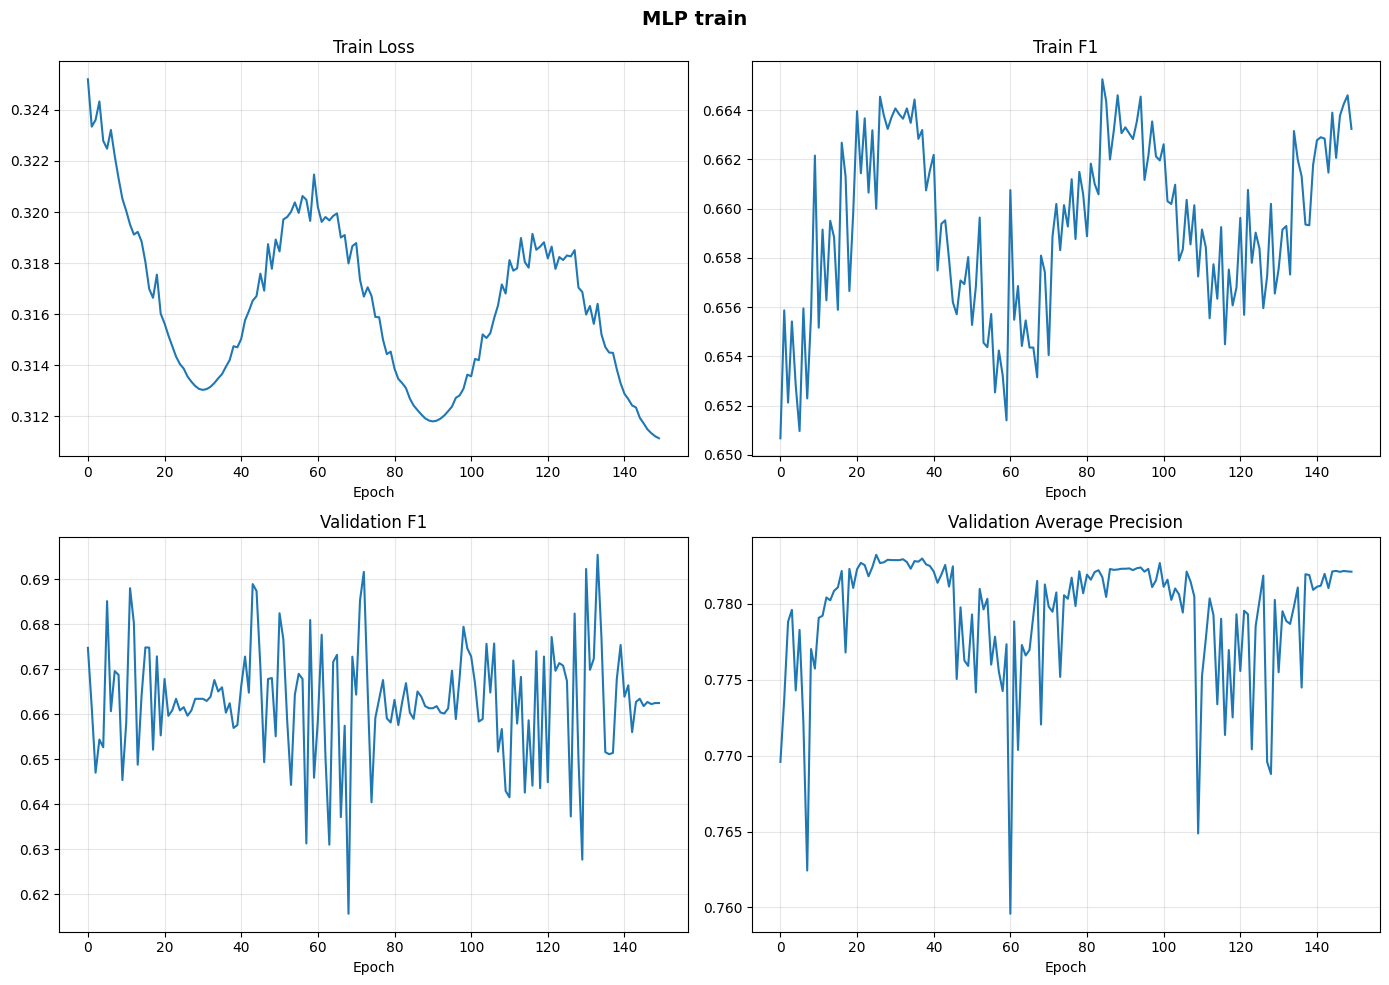

In [754]:
plot_history(mlp_history, "MLP train")

### 3.7.2. Увеличение batch size для стабилизации

**Проблема**: График F1 сильно "дергается" (как пульс) из-за малого batch_size.  

**Решение**: Увеличиваем batch_size с 64 до 256.

In [756]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [757]:
mlp_model = MLP(
    input_dim=in_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"])

Я перезаписал train_loader (и val_loader), но train_model содержит старые train_loader и val_loader (с батчами 64), т.к в функцию сразу передаванлись эти лоадеры:
```python
def train_model(...,
                train_loader=train_loader,
                val_loader=val_loader
                ...)
```
Нужно в функцию передать новые train_loader и val_loader, и, чтобы не сделать в дальнейшем ошибок, дефолтные значения у лоадеров будут теперь None. Код с выполнением подбора параметров я переисполнять не будут - долго он считается; поэтому тут оповещу об изменениях.

```python
def train_model(...,
                train_loader=None,
                val_loader=None
                ...)
```
Теперь нужно явно передавать loader'ы

In [ ]:
mlp_history, mlp_params = train_model(mlp_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=True,
                                      return_best_params=True,
                                      train_loader=train_loader,
                                      val_loader=val_loader)

In [761]:
best_ap = max(mlp_history['val_avg_precision'])
print(f"Лучший AP: {best_ap:.4f}")

Лучший AP: 0.7836


AP был 0.7834, стал 0.7836 - почти не изменился

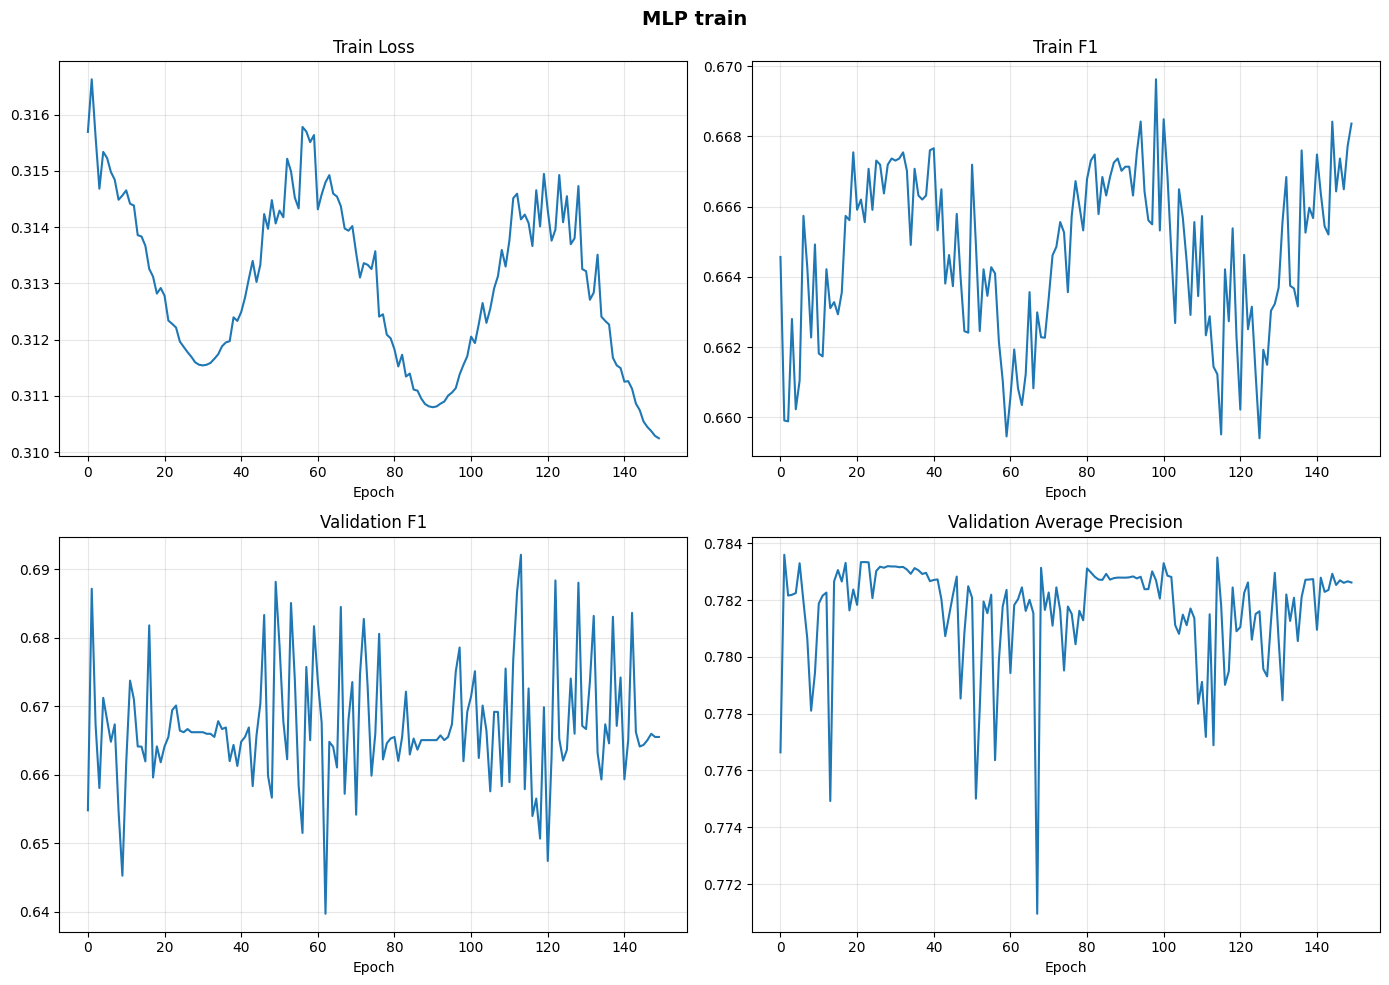

In [763]:
plot_history(mlp_history, "MLP train")

График стал менее хаотичен из-за увеличение batch size

## 3.8. Анализ важности признаков (SHAP)

### 3.8.1. Что такое SHAP?

**SHAP (SHapley Additive exPlanations)** - метод интерпретации моделей, который показывает, какой вклад каждый признак вносит в предсказание.

### 3.8.2. Реализация

In [652]:
import shap

In [664]:
def shap_importance_mlp(model, X, feature_names):
    model.eval()
    
    def predict_proba(X):
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        
        return model(X_tensor).detach().cpu().numpy().flatten()
    
    explainer = shap.KernelExplainer(predict_proba, X[:250])
    shap_values = explainer.shap_values(X[:250])
    
    # Важность - среднее абсолютное значение SHAP
    importance = np.abs(shap_values).mean(axis=0)
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    # Визуализация
    shap.summary_plot(shap_values, X[:250], feature_names=feature_names)
    
    return importance_df

### 3.8.3. Запуск SHAP анализа

In [665]:
len(columns)

27

В колонках есть таргет, нужно убрать

In [666]:
feature_names = columns[::]
feature_names.remove("Target")

In [667]:
len(feature_names)

26

In [668]:
mlp_model = MLP(
    input_dim=in_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"])
mlp_model.load_state_dict(mlp_params)

<All keys matched successfully>

In [669]:
X_val.shape

(6513, 26)

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/250 [00:00<?, ?it/s]

C:\Users\golik\AppData\Local\Temp\ipykernel_9596\3145948933.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[:250], feature_names=feature_names)


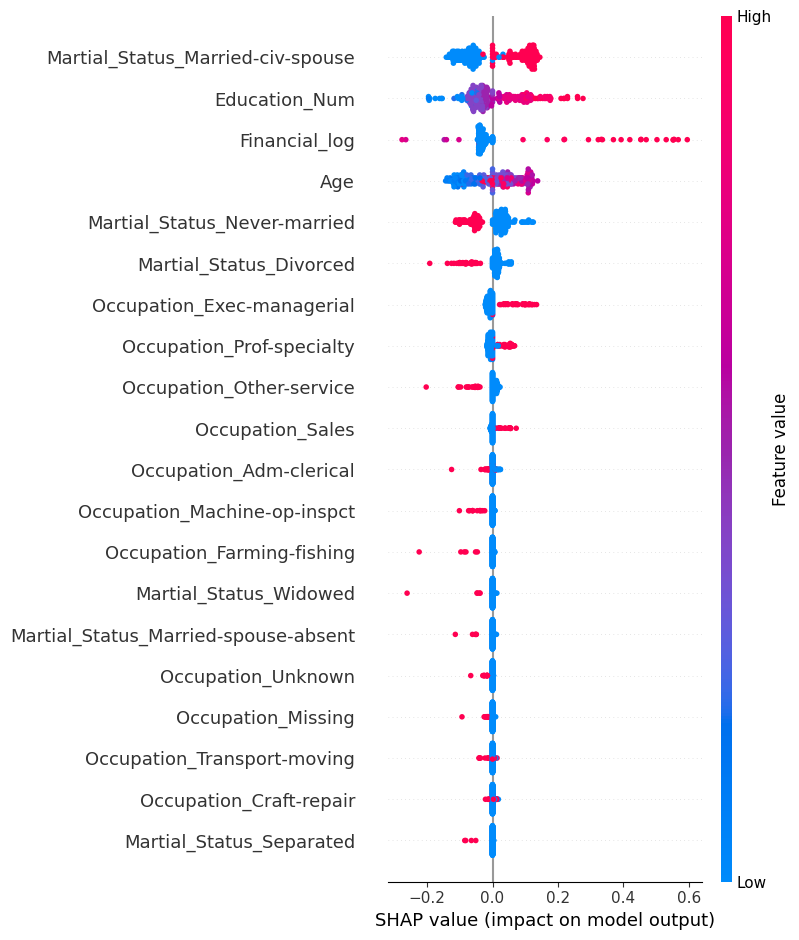

In [670]:
importance_df = shap_importance_mlp(mlp_model, X_val, feature_names)

### 3.8.4. Результаты SHAP анализа

In [671]:
importance_df

,feature,importance
5,Martial_Status_Married-civ-spouse,0.085227
1,Education_Num,0.067568
25,Financial_log,0.065389
0,Age,0.065326
7,Martial_Status_Never-married,0.043371
3,Martial_Status_Divorced,0.023516
13,Occupation_Exec-managerial,0.019119
19,Occupation_Prof-specialty,0.014178
17,Occupation_Other-service,0.012361
21,Occupation_Sales,0.005472


### 3.8.5. Ключевые выводы

- Семейное положение - самый важный фактор (суммарная важность ~0.17)
- образование - второй по важности признак
- возраст и финансовое состояние также значимы
- профессиональные признаки имеют умеренную важность
- признаки с нулевой важностью (Occupation_Armed-Forces, Occupation_Priv-house-serv и др.) скорее всего связаны с тем, что для shap я использовал небольшую подвыборку (250) и из-за этого эти признаки могли не войти туда  

## 3.9. Эксперимент с новыми признаками (Feature Engineering)

### 3.9.1. Какие признаки были добавлены

In [674]:
adult['Age_x_Financial'] = adult['Age'] * adult['Financial_log']

Влияние финансов на поведение зависит от возраста

In [675]:
adult['Edu_x_Financial'] = adult['Education_Num'] * adult['Financial_log']

Высокое образование + высокий доход - довольно обычный случай, а низкое образование + высокий доход - редкий случай.

Квадраты:

In [676]:
adult['Age_sq'] = adult['Age'] ** 2

In [677]:
adult['Edu_sq'] = adult['Education_Num'] ** 2

Возраст и число образования могут быть связаны нелинейно

### 3.9.2. Подготовка dataset и dataloader для данных с доп. признаками

In [681]:
columns_new = adult.columns.tolist()
columns_new

['Age',
 'Education_Num',
 'Target',
 'Occupation_Missing',
 'Martial_Status_Divorced',
 'Martial_Status_Married-AF-spouse',
 'Martial_Status_Married-civ-spouse',
 'Martial_Status_Married-spouse-absent',
 'Martial_Status_Never-married',
 'Martial_Status_Separated',
 'Martial_Status_Widowed',
 'Occupation_Adm-clerical',
 'Occupation_Armed-Forces',
 'Occupation_Craft-repair',
 'Occupation_Exec-managerial',
 'Occupation_Farming-fishing',
 'Occupation_Handlers-cleaners',
 'Occupation_Machine-op-inspct',
 'Occupation_Other-service',
 'Occupation_Priv-house-serv',
 'Occupation_Prof-specialty',
 'Occupation_Protective-serv',
 'Occupation_Sales',
 'Occupation_Tech-support',
 'Occupation_Transport-moving',
 'Occupation_Unknown',
 'Financial_log',
 'Age_x_Financial',
 'Edu_x_Financial',
 'Age_sq',
 'Edu_sq']

In [682]:
X_adult_new, y_adult_new = adult.drop(columns=["Target"]).values.astype(np.float32), adult.Target.astype(np.float32).values

#### Делим на train и val

In [683]:
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_adult_new, y_adult_new, test_size=0.2, random_state=SEED, stratify=y_adult_new
)

#### Создаем train датасет и даталоадер

In [684]:
X_train_tenzor = torch.tensor(X_train_new, dtype=torch.float32)
y_train_tenzor = torch.tensor(y_train_new, dtype=torch.float32).view(-1, 1)

In [765]:
train_dataset_new = TensorDataset(X_train_tenzor, y_train_tenzor)
train_loader_new = DataLoader(train_dataset_new, batch_size=256, shuffle=True)

#### Создаем validation датасет и даталоадер

In [686]:
X_val_tenzor = torch.tensor(X_val_new, dtype=torch.float32)
y_val_tenzor = torch.tensor(y_val_new, dtype=torch.float32).view(-1, 1)

In [766]:
val_dataset_new = TensorDataset(X_val_tenzor, y_val_tenzor)
val_loader_new = DataLoader(val_dataset_new, batch_size=256, shuffle=False)

#### Проверка

In [ ]:
it = iter(val_loader_new)
next(it)

In [ ]:
it = iter(train_loader_new)
next(it)

In [691]:
del it

### 3.9.3. Обучаем MLP на данных с доп. признаками

#### Обучение модели

In [693]:
in_dim_new = X_train_tenzor.shape[-1]

In [694]:
in_dim_new

30

In [697]:
# mlp_model.load_state_dict(torch.load('best_pretrained_mlp_weights.pth'))

In [767]:
mlp_model = MLP(
    input_dim=in_dim_new,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"])

In [ ]:
model_history, model_params = train_model(mlp_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=True,
                                      return_best_params=True,
                                      train_loader=train_loader_new,
                                      val_loader=val_loader_new)

In [769]:
best_ap = max(model_history['val_avg_precision'])
print(f"Лучший AP: {best_ap:.4f}")

Лучший AP: 0.7808


Максимальный AP score при обучении с доп. признаками равен 0.7808, когда без доп. признаков результат 0.7836

##### Вывод из обучения MLP с доп. признаками

Модель с доп. признаками равна 0.7808 AP, что явно хуже модели без доп. признаков (0.7836)

#### Графики обучения

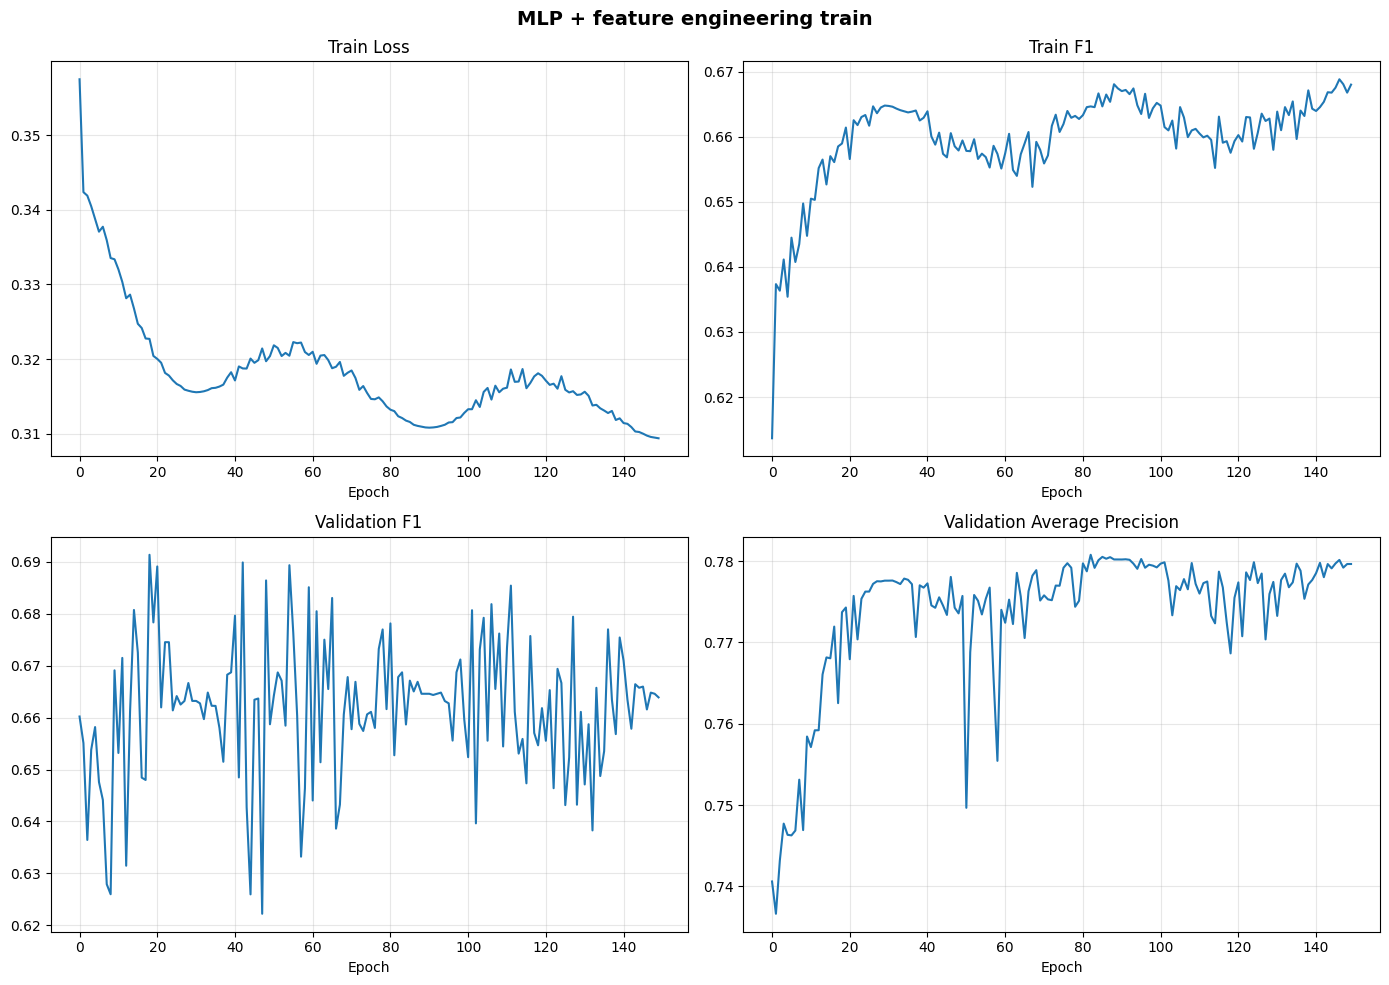

In [770]:
plot_history(model_history, "MLP + feature engineering train")

### 3.9.3. SHAP для оценки важности признаков

In [706]:
feature_names_new = columns_new[::]
feature_names_new.remove("Target")

Using 250 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/250 [00:00<?, ?it/s]

C:\Users\golik\AppData\Local\Temp\ipykernel_9596\3145948933.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X[:250], feature_names=feature_names)


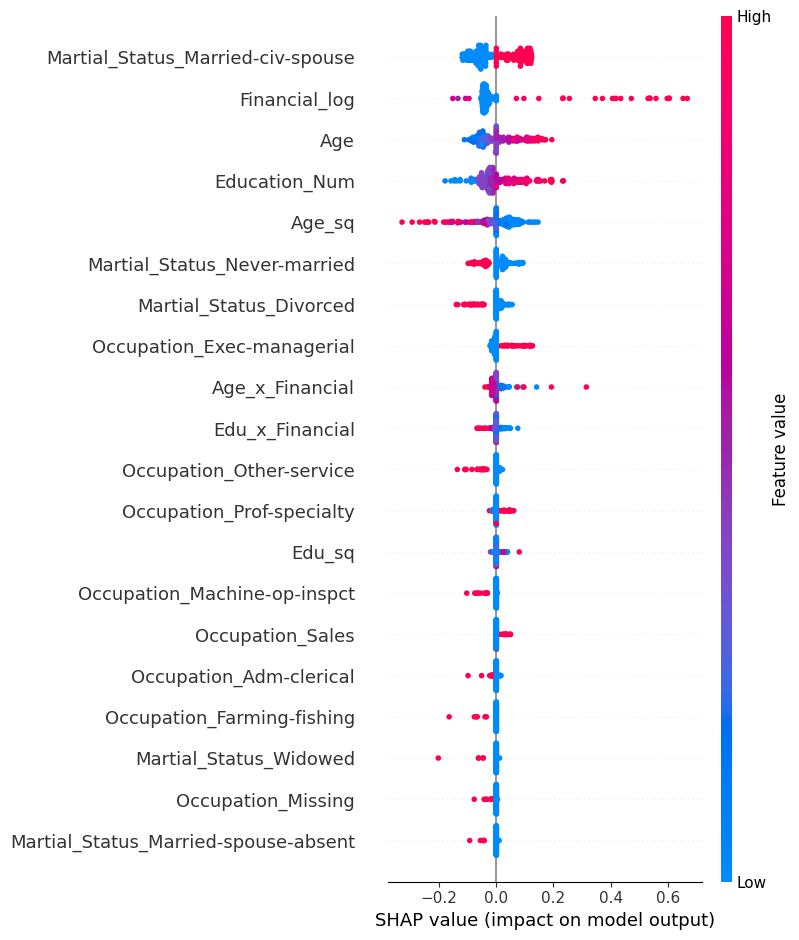

In [708]:
importance_df_new = shap_importance_mlp(mlp_model, X_val_new, feature_names_new)

In [709]:
importance_df_new

,feature,importance
5,Martial_Status_Married-civ-spouse,0.071956
25,Financial_log,0.071185
0,Age,0.054585
1,Education_Num,0.052318
28,Age_sq,0.052316
7,Martial_Status_Never-married,0.031600
3,Martial_Status_Divorced,0.019696
13,Occupation_Exec-managerial,0.016101
26,Age_x_Financial,0.013032
27,Edu_x_Financial,0.009013


Только `Age_sq` вошел в топ-5, остальные признаки остались менее важны для модели

### 3.9.4. Вывод из feature engineering

- Базовый MLP - 0.7836 AP
- \+ новые признаки - 0.7808 AP

Разница на -0.0028

Вывод: новые признаки не улучшили качество, а даже ухудшили его. Это может быть связано с тем, что модель уже достигла предела с текущими признаками.

## 3.10. Эксперимент с Focal Loss

### 3.10.1. Что такое Focal Loss?

Focal Loss - модификация кросс-энтропии, которая фокусируется на трудных примерах, уменьшая вклад хорошо классифицированных. Это особенно полезно при дисбалансе классов.

### 3.10.2. Реализация

In [723]:
import torch.nn.functional as F

In [724]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        """
        Focal Loss для бинарной классификации.

        Parameters
        ----------
        alpha : torch.Tensor
            Веса классов размером [2] для [класс_0, класс_1].
            Пример: torch.tensor([0.75, 0.25])
        gamma : float
            Параметр фокусировки. По умолчанию 2.0.
        reduction : str
            'mean', 'sum' или 'none'.
        """
        super().__init__()
        # Гарантируем, что alpha - это тензор с плавающей точкой
        self.alpha = alpha.float()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        inputs : torch.Tensor
            Логиты модели (без сигмоиды), форма [Batch, ...]
        targets : torch.Tensor
            Метки классов (0 или 1), форма [Batch, ...]
        """
        assert inputs.shape == targets.shape, f"Shape mismatch: {inputs.shape} vs {targets.shape}"

        # Приводим targets к long для gather и float для BCE
        targets_long = targets.long()
        targets_float = targets.float()

        # 1. Бинарная кросс-энтропия без редукции
        bce_loss = F.binary_cross_entropy(inputs, targets_float, reduction="none")

        # 2. Вероятность правильного класса (p_t)
        p_t = torch.exp(-bce_loss)

        # 3. Выбор веса alpha для каждого пикселя/элемента
        # Перемещаем alpha на то же устройство, что и данные
        alpha = self.alpha.to(inputs.device)

        # gather выбирает вес: если target=0 -> alpha[0], если target=1 -> alpha[1]
        alpha_t = alpha.gather(0, targets_long.view(-1)).view_as(targets)

        # 4. Фокусирующий коэффициент (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma

        # 5. Итоговый лосс
        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

### 3.10.3. Подбор `alpha`

Рассчитаем `alpha` - веса классов

In [713]:
# Обратная частота
total = len(y_train)
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

alpha_0 = total / (2 * n_neg)
alpha_1 = total / (2 * n_pos)
alpha = torch.tensor([alpha_0, alpha_1])

In [714]:
alpha

tensor([0.6586, 2.0762], dtype=torch.float64)

### 3.10.4. Обучениe MLP с Focal loss

In [734]:
focal_loss_criterion = FocalLoss(alpha=alpha, gamma=2.0)

In [999]:
mlp_model = MLP(
    input_dim=in_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"])

In [ ]:
mlp_history, mlp_params = train_model(mlp_model, 
                                      epochs=180, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=True,
                                      return_best_params=True,
                                      train_loader=train_loader,
                                      val_loader=val_loader,
                                      criterion=focal_loss_criterion)

### 3.10.5. Результат VAL AP

In [773]:
best_ap = max(mlp_history['val_avg_precision'])
print(f"Лучший AP: {best_ap:.4f}")

Лучший AP: 0.7838


### 3.10.6. Графики обучения

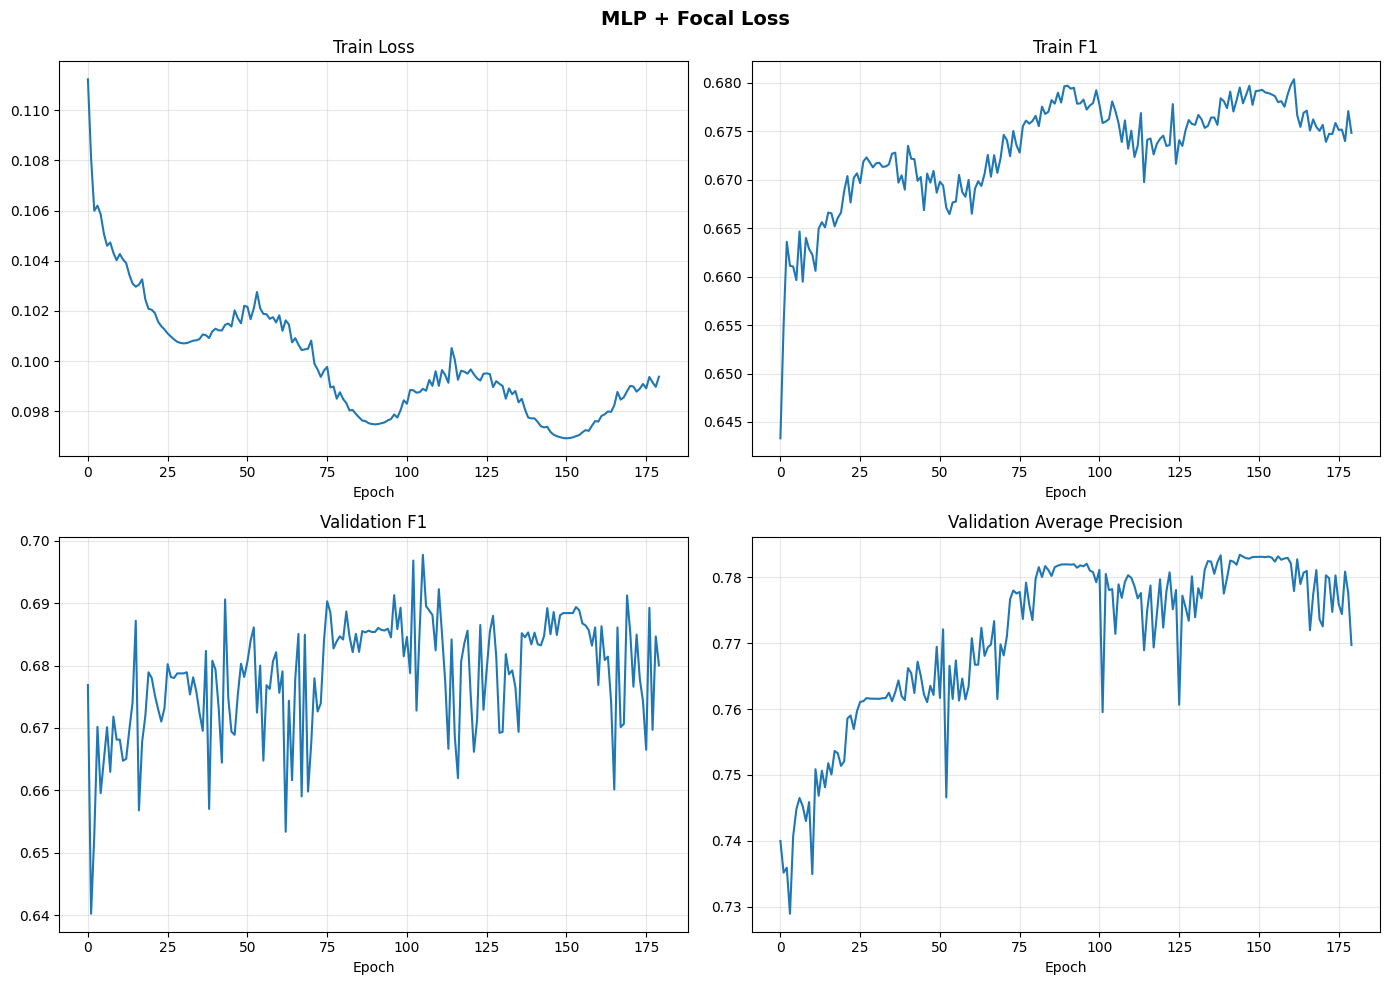

In [1001]:
plot_history(mlp_history, "MLP + Focal Loss")

### 3.10.7. Результаты

Лучший AP после обучения равен 0.7838, когда без Focal Loss он равен 0.7836. Разница небольшая (0.0002), можно сказать, что использование Focal Loss никак не повлиял на лучший AP модели. Можно сказать, что модель уже преодолела максимум с текущими признаками.

Можно также заметить, что модель с focal loss дольше сходится к Val AP равному 0.78, но все равно на максимальный val ap это никак не повлияло. График validation f1 стал менее хаотичнее, чем график val f1 без Focal Loss.

Я также поставил 180 эпох вместо 150 и на графике train loss можно заметить, что дальше 175 эпохи лосс начинает сильно расти, а значит ~150 эпоха является оптимальной

## 3.11. Исправление ошибки (корреляции)

### 3.11.1. В чем ошибка?

После экспериментов с pre-trained MLP я заметил:
- Колонку `Occupation_Missing` я добавлял как флаг наличия пропуска в колонке `Occupation`, потом заполнил пропуски значением "Unknown", далее сделал one-hot кодирование у `Occupation`, и по сути `Occupation_Missing` и `Occupation_Unknown` будут одинаковыми, а значит эти два признака идеально *скоррелированы*.

Нужно избавиться от одной из колонок и заного провести обучение MLP

### 3.11.2. Удаление `Occupation_Missing`

In [965]:
adult.columns

Index(['Age', 'Education_Num', 'Target', 'Occupation_Missing',
       'Martial_Status_Divorced', 'Martial_Status_Married-AF-spouse',
       'Martial_Status_Married-civ-spouse',
       'Martial_Status_Married-spouse-absent', 'Martial_Status_Never-married',
       'Martial_Status_Separated', 'Martial_Status_Widowed',
       'Occupation_Adm-clerical', 'Occupation_Armed-Forces',
       'Occupation_Craft-repair', 'Occupation_Exec-managerial',
       'Occupation_Farming-fishing', 'Occupation_Handlers-cleaners',
       'Occupation_Machine-op-inspct', 'Occupation_Other-service',
       'Occupation_Priv-house-serv', 'Occupation_Prof-specialty',
       'Occupation_Protective-serv', 'Occupation_Sales',
       'Occupation_Tech-support', 'Occupation_Transport-moving',
       'Occupation_Unknown', 'Financial_log', 'Age_x_Financial',
       'Edu_x_Financial', 'Age_sq', 'Edu_sq'],
      dtype='object')

Удаляем признаки, которые были добавлены в пунке Feature Engineering (потому что я перезаписывал переменную adult) и удаляем еще `Occupation_Missing`

In [966]:
adult_df = adult.drop(columns=["Age_x_Financial", "Edu_x_Financial", "Age_sq", "Edu_sq", "Occupation_Missing"])

In [977]:
len(adult_df.columns)

26

### 3.11.3. Подготовление данных для обучения сети

Разделение на признаки и целевую переменную

In [968]:
X_adult_df, y_adult_df = adult_df.drop(columns=["Target"]).values.astype(np.float32), adult_df.Target.astype(np.float32).values

Разделение на train и val

In [969]:
X_train, X_val, y_train, y_val = train_test_split(
    X_adult_df, y_adult_df, test_size=0.2, random_state=SEED, stratify=y_adult_df
)

Train dataset и data loader

In [970]:
X_train_df_t = torch.tensor(X_train, dtype=torch.float32)
y_train_df_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

In [972]:
adult_train_dataset = TensorDataset(X_train_df_t, y_train_df_t)
adult_train_loader = DataLoader(adult_train_dataset, batch_size=256, shuffle=True)

Validation dataset и data loader

In [971]:
X_val_df_t = torch.tensor(X_val, dtype=torch.float32)
y_val_df_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

In [973]:
adult_val_dataset = TensorDataset(X_val_df_t, y_val_df_t)
adult_val_loader = DataLoader(adult_val_dataset, batch_size=256, shuffle=False)

### 3.11.4. Обучение

In [976]:
input_dim = X_train_df_t.shape[-1]
input_dim

25

In [1063]:
mlp_model = MLP(
    input_dim=input_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"])

In [1064]:
# focal loss не дал никакого прироста модели, но можно его оставить

In [ ]:
mlp_history, mlp_params = train_model(mlp_model, 
                                      epochs=180, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=True,
                                      return_best_params=True,
                                      train_loader=adult_train_loader,
                                      val_loader=adult_val_loader)

### 3.11.5. Результат Val AP

In [996]:
best_ap = max(mlp_history['val_avg_precision'])
print(f"Лучший AP: {best_ap:.4f}")

Лучший AP: 0.7840


### 3.11.6. Графики обучения

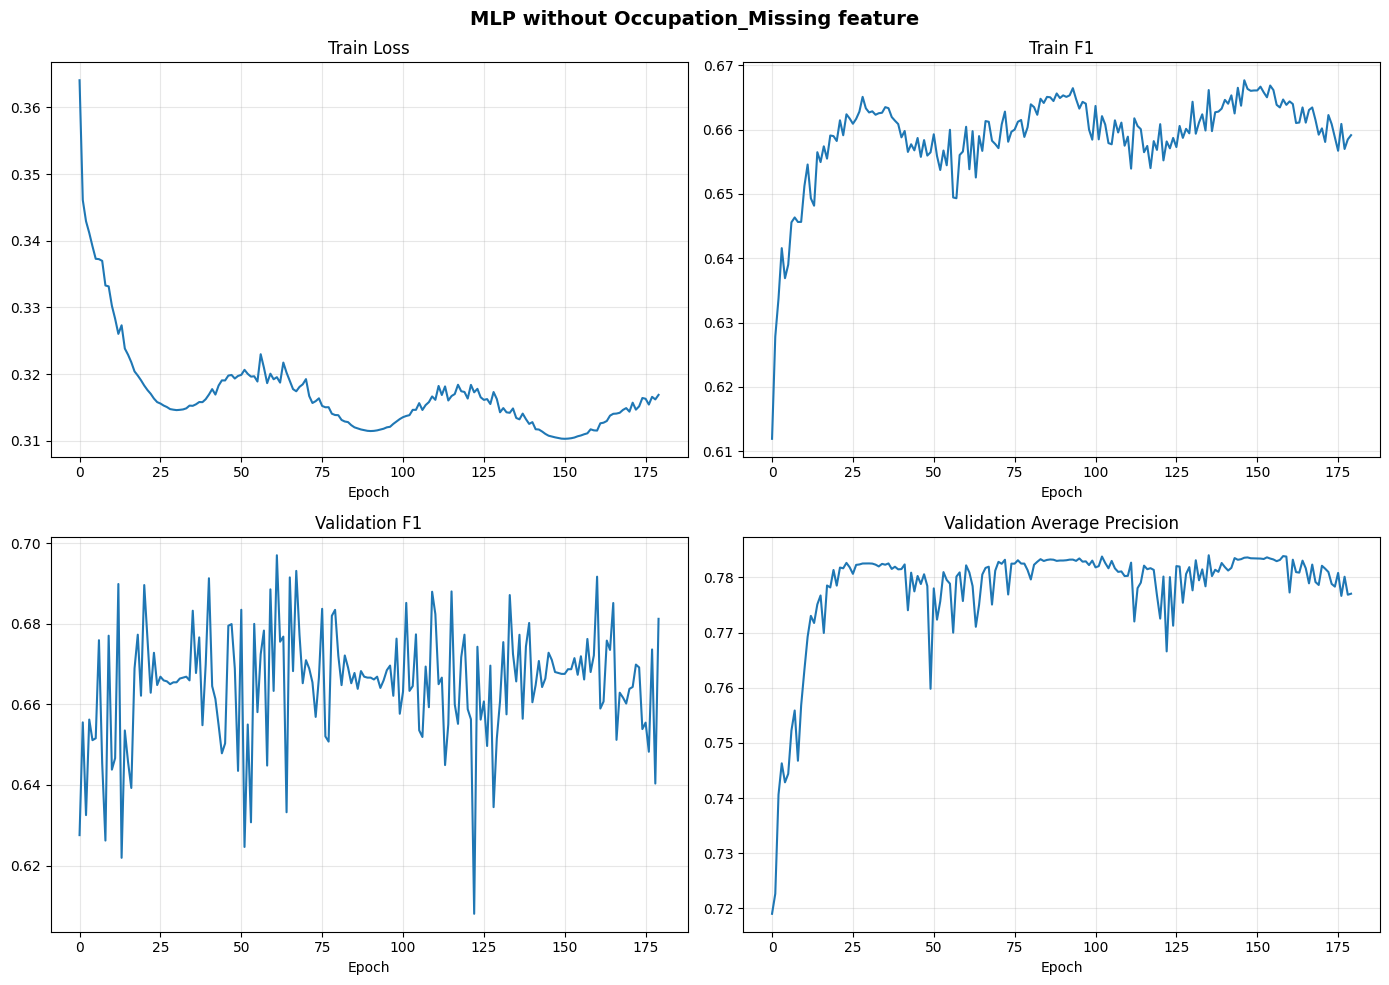

In [998]:
plot_history(mlp_history, "MLP without Occupation_Missing feature")

### 3.11.7. Результат

Лучший validation average precision равен 0.7840. После удаления `Occupation Missing` эта метрика немного возрасла (на 0.0004), но это можно списать на погрешность, поэтому удаление этого признака не повлияло на модель. Но удалить этот признак было не лишним.

## 3.12. Сохранение модели для Transfer Learning

In [1003]:
import joblib

In [1068]:
# Сохраняем лучшие веса
torch.save(mlp_params, 'best_pretrained_mlp_weights.pth')

# Сохраняем encoder и scaler для использования с Bank
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# 4. Transfer Learning

## 4.1. Переход от Adult к Bank Marketing

Что уже есть:
1. Предобученная MLP на Adult (AP = 0.7838)
2. Сохранённые веса (`best_pretrained_mlp_weights.pth`)
3. Сохранённые трансформеры (`encoder.pkl`, `scaler.pkl`)

Что нужно делать:
1. Загрузить и обработать Bank Marketing датасет (те же преобразования, что и в Adult)
2. Загрузить предобученную модель
3. Заморозить начальные слои модели
4. Дообучить модель на Bank Marketing
5. Обучить MLP с нуля
6. Обучить методы классического ml на Bank Marketing
7. Сравнить результаты и сделать вывод

## 4.2. Бизнес-задача и метрики для Bank Marketing

### 4.2.1. Бизнес-задача

Данные Bank Marketing связаны с **прямыми маркетинговыми кампаниями** португальского банка.

**Суть задачи:**  
Предсказать, согласится ли клиент оформить **срочный банковский вклад (term deposit)** на основе исторических данных о маркетинговых контактах.

**Бизнес-контекст:**  
Банк проводит телефонные кампании для привлечения клиентов к открытию депозитов. Каждый звонок требует времени и ресурсов операторов.  
Задача модели - **выявить клиентов с высокой вероятностью оформления депозита**, чтобы:  
- оптимизировать бюджет на маркетинг (звонить только "горячим" клиентам)
- повысить конверсию кампании
- снизить нагрузку на операторов

**Целевая переменная:**  
`y` - факт оформления депозита (`yes` / `no`)

---


### 4.2.2. Выбор основной метрики

В качестве основной метрики был выбран AP (average precision). F1 - вспомогательная метрика:

| Метрика | Проблема | Решение |
| :--- | :--- | :--- |
| **Accuracy** | Классы сильно несбалансированы (~88% `no`, ~12% `yes`). Accuracy будет вводить в заблуждение | **Не используем** |
| **F1-Score** | Хорош для баланса Precision/Recall, но зависит от порога | Используем как **вспомогательную** |
| **Average Precision (AP)** | Устойчива к дисбалансу, показывает ранжирование | **Основная метрика** |

**Почему AP важна именно здесь:**  
Банку важно **отранжировать** клиентов по вероятности оформления депозита. Например, чтобы позвонить топ-10% самых перспективным клиентам. AP показывает, насколько хорошо модель ранжирует клиентов.

**Итог:** Основная метрика - **Average Precision (AP)**. Вспомогательная - **F1-Score**.

---

## 4.3. Обработка данных Bank Marketing

### 4.3.1. Загрузка bank marketing данных

In [863]:
bank_data = pd.read_csv("data/bank/bank.csv", sep=";")

In [844]:
bank_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


### 4.3.2. Переименовые колонок в соответствии с Adult данными

Переименовывать нужно, потому что one-hot encoder и standart scaler обучены на названиях колонок из Adult данных, поэтому такой нейминг нужно сделать подходящим колонкам в Bank Marketing

In [864]:
# Переименовываем колонки под Adult
bank_data = bank_data.rename(columns={
    'age': 'Age',
    'marital': 'Martial_Status',
    'job': 'Occupation',
    'education': 'Education',
    'balance': 'Financial',
    'y': "Target"
})

In [827]:
bank_data.head()

,Age,Occupation,Martial_Status,Education,default,Financial,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [849]:
adult_cols = [
    'Age',
    "Education_Num",
    'Martial_Status',
    'Occupation',
    'Financial',
    'Target'
]

### 4.3.3. Просмотр "общих" колонок у Adult и Bank датасетов

#### Martial_Status

In [957]:
print("Adult martial status")
adult_data.Martial_Status.unique()

Adult martial status


array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [958]:
print("Bank martial status")
bank_data.Martial_Status.unique()

Bank martial status


array(['Married-civ-spouse', 'Never-married', 'Divorced'], dtype=object)

#### Education

In [813]:
print("Adult education")
adult_data.Education.unique()

Adult education


array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [814]:
print("Bank Marketing education")
bank_data.Education.unique()

Bank Marketing education


array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object)

У Adult в education нет пропусков, а у Bank есть. Следовательно у Bank датасета нужно заполнить эти пропуски. Заполним модой по признаку 

In [865]:
mode_education = bank_data['Education'].mode()[0]

In [866]:
mode_education

'secondary'

In [867]:
bank_data['Education'] = bank_data['Education'].replace('unknown', mode_education)

In [868]:
print("Bank Marketing education")
bank_data.Education.unique()

Bank Marketing education


array(['primary', 'secondary', 'tertiary'], dtype=object)

In [820]:
education

,Education,Education_Num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


#### Occupation

In [817]:
print("Adult occupation")
adult_data.Occupation.unique()

Adult occupation


array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', nan, ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [819]:
print("Bank Marketing occupation")
bank_data.Occupation.unique()

Bank Marketing occupation


array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

Нужно переименовывать значения из Bank Marketing на значения как у Adult датасета

### 4.3.4. Переименовывание значений в Bank

In [852]:
marital_mapping = {
    'married': 'Married-civ-spouse',
    'single': 'Never-married',
    'divorced': 'Divorced'
}

In [869]:
education_mapping = {
    'primary': 'HS-grad',
    'secondary': 'Some-college',
    'tertiary': 'Bachelors',
}

In [870]:
occupation_mapping = {
    'management': 'Exec-managerial',
    'admin.': 'Adm-clerical',
    'technician': 'Tech-support',
    'services': 'Other-service',
    'blue-collar': 'Craft-repair',
    'self-employed': 'Unknown',
    'entrepreneur': 'Unknown',
    'unemployed': 'Unknown',
    'student': 'Unknown',
    'retired': 'Unknown',
    'housemaid': 'Priv-house-serv',
    'unknown': 'Unknown'
}

In [871]:
bank_data['Martial_Status'] = bank_data['Martial_Status'].map(marital_mapping)
bank_data['Education'] = bank_data['Education'].map(education_mapping)
bank_data['Occupation'] = bank_data['Occupation'].map(occupation_mapping)

### 4.3.5. Проверка преобразования

#### Martial Status

In [872]:
bank_data.Martial_Status.unique()

array(['Married-civ-spouse', 'Never-married', 'Divorced'], dtype=object)

In [873]:
adult_data.Martial_Status.unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

#### Education

In [874]:
bank_data.Education.unique()

array(['HS-grad', 'Some-college', 'Bachelors'], dtype=object)

In [875]:
adult_data.Education.unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

#### Occupation

In [876]:
bank_data.Occupation.unique()

array(['Unknown', 'Other-service', 'Exec-managerial', 'Craft-repair',
       'Tech-support', 'Adm-clerical', 'Priv-house-serv'], dtype=object)

In [877]:
adult_data.Occupation.unique()

array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', nan, ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

### 4.3.6. Добавление Education_Num

In [878]:
bank_data.head()

,Age,Occupation,Martial_Status,Education,default,Financial,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,30,Unknown,Married-civ-spouse,HS-grad,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,Other-service,Married-civ-spouse,Some-college,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,Exec-managerial,Never-married,Bachelors,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,Exec-managerial,Married-civ-spouse,Bachelors,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,Craft-repair,Married-civ-spouse,Some-college,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [1139]:
edu_mapping

{'Preschool': 1,
 '1st-4th': 2,
 '5th-6th': 3,
 '7th-8th': 4,
 '9th': 5,
 '10th': 6,
 '11th': 7,
 '12th': 8,
 'HS-grad': 9,
 'Some-college': 10,
 'Assoc-voc': 11,
 'Assoc-acdm': 12,
 'Bachelors': 13,
 'Masters': 14,
 'Prof-school': 15,
 'Doctorate': 16}

In [879]:
edu_mapping = education.set_index('Education')['Education_Num'].to_dict()

In [882]:
bank_data['Education_Num'] = bank_data['Education'].map(edu_mapping)

### 4.3.7. One-hot кодирование признаков

- One-hot кодирование нужно применить такое, которое было сделано при обработке Adult данных

In [890]:
columns = [
    'Age',
    'Education_Num',
    'Financial',
    'Martial_Status',
    "Occupation",
    'Target'
]

In [902]:
bank = bank_data[columns]

In [903]:
bank.head()

,Age,Education_Num,Financial,Martial_Status,Occupation,Target
0,30,9,1787,Married-civ-spouse,Unknown,no
1,33,10,4789,Married-civ-spouse,Other-service,no
2,35,13,1350,Never-married,Exec-managerial,no
3,30,13,1476,Married-civ-spouse,Exec-managerial,no
4,59,10,0,Married-civ-spouse,Craft-repair,no


Признаки, которые будем кодировать

In [904]:
bank_cat = bank[["Martial_Status", "Occupation"]]

Применяем one-hot кодирование, которое делали в adult dataset

In [1006]:
# encoder = joblib.load('encoder.pkl')

In [905]:
bank_encoded = encoder.transform(bank_cat)
bank_encoded_df = pd.DataFrame(
    bank_encoded,
    columns=encoder.get_feature_names_out(['Martial_Status', 'Occupation']),
    index=bank.index
)

Соединяем one-hot колонки 

In [906]:
bank = pd.concat([bank, bank_encoded_df], axis=1)

Удаляем ненужные колонки

In [898]:
bank = bank.drop(columns=['Martial_Status', 'Occupation'])

### 4.3.8. Стандартизация признаков

- Стандартизацию нужно делать также, как это было и в Adult dataset. То есть использовать обученый `StandartScaler` на Adult данных

In [1005]:
bank_numeric = ["Age", "Education_Num", "Financial_log"]

Обрезаем значения ниже нуля, как это делали и с Adult данными

In [908]:
bank['Financial'] = bank['Financial'].clip(lower=0)

Логарифмируем `Financial` как с Adult

In [909]:
bank['Financial_log'] = np.log1p(bank['Financial'])

Применяем обученный scaler

In [916]:
bank[bank_numeric] = scaler.transform(bank[bank_numeric])

In [ ]:
bank = bank.drop(columns=["Financial", "Martial_Status", "Occupation"])

In [1019]:
len(adult_cols)

26

In [1140]:
adult_cols

['Age',
 'Education_Num',
 'Target',
 'Martial_Status_Divorced',
 'Martial_Status_Married-AF-spouse',
 'Martial_Status_Married-civ-spouse',
 'Martial_Status_Married-spouse-absent',
 'Martial_Status_Never-married',
 'Martial_Status_Separated',
 'Martial_Status_Widowed',
 'Occupation_Adm-clerical',
 'Occupation_Armed-Forces',
 'Occupation_Craft-repair',
 'Occupation_Exec-managerial',
 'Occupation_Farming-fishing',
 'Occupation_Handlers-cleaners',
 'Occupation_Machine-op-inspct',
 'Occupation_Other-service',
 'Occupation_Priv-house-serv',
 'Occupation_Prof-specialty',
 'Occupation_Protective-serv',
 'Occupation_Sales',
 'Occupation_Tech-support',
 'Occupation_Transport-moving',
 'Occupation_Unknown',
 'Financial_log']

In [1020]:
assert len(adult_cols) == len(bank.columns)

In [1021]:
bank = bank[adult_cols]

In [1022]:
bank.describe()

,Age,Education_Num,Martial_Status_Divorced,Martial_Status_Married-AF-spouse,Martial_Status_Married-civ-spouse,Martial_Status_Married-spouse-absent,Martial_Status_Never-married,Martial_Status_Separated,Martial_Status_Widowed,Occupation_Adm-clerical,...,Occupation_Machine-op-inspct,Occupation_Other-service,Occupation_Priv-house-serv,Occupation_Prof-specialty,Occupation_Protective-serv,Occupation_Sales,Occupation_Tech-support,Occupation_Transport-moving,Occupation_Unknown,Financial_log
count,4521.000000,4521.000000,4521.000000,4521.0,4521.000000,4521.0,4521.000000,4521.0,4521.0,4521.000000,...,4521.0,4521.000000,4521.000000,4521.0,4521.0,4521.0,4521.000000,4521.0,4521.000000,4521.000000
mean,0.189766,0.258553,0.116788,0.0,0.618668,0.0,0.264543,0.0,0.0,0.105729,...,0.0,0.092236,0.024773,0.0,0.0,0.0,0.169874,0.0,0.183809,1.874230
std,0.775369,0.587134,0.321203,0.0,0.485767,0.0,0.441138,0.0,0.0,0.307524,...,0.0,0.289391,0.155451,0.0,0.0,0.0,0.375564,0.0,0.387371,1.140374
min,-1.435581,-0.420060,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,-0.299271
25%,-0.409205,-0.031360,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,1.431488
50%,0.030671,-0.031360,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,2.184973
75%,0.763796,1.134739,0.000000,0.0,1.000000,0.0,1.000000,0.0,0.0,0.000000,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,2.674808
max,3.549675,1.134739,1.000000,0.0,1.000000,0.0,1.000000,0.0,0.0,1.000000,...,0.0,1.000000,1.000000,0.0,0.0,0.0,1.000000,0.0,1.000000,4.252443


### 4.3.9. Обработка значений у Target колонки

In [1025]:
bank.Target.unique()

array(['no', 'yes'], dtype=object)

In [1027]:
bank.Target.value_counts()

Target
no     4000
yes     521
Name: count, dtype: int64

Нужно переименовать значения в Target колонке в 0 и 1

In [1026]:
bank_target_map = {'no': 0, 'yes': 1}

In [1028]:
bank.Target = bank.Target.map(bank_target_map)

Проверка

In [1029]:
bank.Target.value_counts()

Target
0    4000
1     521
Name: count, dtype: int64

## 4.4. Подготовка Bank данных для Transfer Learning

In [1033]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   4521 non-null   float64
 1   Education_Num                         4521 non-null   float64
 2   Target                                4521 non-null   int64  
 3   Martial_Status_Divorced               4521 non-null   float64
 4   Martial_Status_Married-AF-spouse      4521 non-null   float64
 5   Martial_Status_Married-civ-spouse     4521 non-null   float64
 6   Martial_Status_Married-spouse-absent  4521 non-null   float64
 7   Martial_Status_Never-married          4521 non-null   float64
 8   Martial_Status_Separated              4521 non-null   float64
 9   Martial_Status_Widowed                4521 non-null   float64
 10  Occupation_Adm-clerical               4521 non-null   float64
 11  Occupation_Armed-

In [1030]:
X_bank, y_bank = bank.drop(columns=["Target"]).values.astype(np.float32), bank.Target.astype(np.float32).values

In [1034]:
X_bank_train, X_bank_val, y_bank_train, y_bank_val = train_test_split(
    X_bank, y_bank, test_size=0.2, random_state=SEED, stratify=y_bank
)

In [1036]:
y_bank.mean()

0.11523999

In [1088]:
X_train_bank_t = torch.tensor(X_bank_train, dtype=torch.float32)
y_train_bank_t = torch.tensor(y_bank_train, dtype=torch.float32).view(-1, 1)

In [1101]:
bank_train_dataset = TensorDataset(X_train_bank_t, y_train_bank_t)
bank_train_loader = DataLoader(bank_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [1090]:
X_val_bank_t = torch.tensor(X_bank_val, dtype=torch.float32)
y_val_bank_t = torch.tensor(y_bank_val, dtype=torch.float32).view(-1, 1)

In [1102]:
bank_val_dataset = TensorDataset(X_val_bank_t, y_val_bank_t)
bank_val_loader = DataLoader(bank_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [1103]:
# BATCH_SIZE = 64

## 4.5. Загрузка pre-trained модели

### 4.5.1. Загрузка

In [1042]:
best_mlp_config

{'hidden_sizes': [512, 256, 128],
 'activation': torch.nn.modules.activation.SELU,
 'dropout': 0.0,
 'use_bn': False}

In [1073]:
train_config

{'lr': 0.001,
 'weight_decay': 0.0001,
 'optimizer': torch.optim.adam.Adam,
 'scheduler': functools.partial(<class 'torch.optim.lr_scheduler.CosineAnnealingLR'>, T_max=30)}

In [1053]:
input_bank_dim = len(X_train_bank_t[0])
input_bank_dim

25

In [1100]:
pretrained_model = MLP(
    input_dim=input_bank_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"]
)
pretrained_model.load_state_dict(torch.load('best_pretrained_mlp_weights.pth'))

<All keys matched successfully>

### 4.5.1. Заморозка всех слоев модели кроме последнего

Посмотрим все слои

In [1104]:
for name, param in pretrained_model.named_parameters():
    print(name)

net.0.weight
net.0.bias
net.2.weight
net.2.bias
net.4.weight
net.4.bias
net.6.weight
net.6.bias


> `net.6` - последний слой перед сигмоидой, поэтому именно его нужно адаптировать под новую задачу (Bank Marketing). 

In [1105]:
for name, param in pretrained_model.named_parameters():
    if 'net.6' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

Проверка, что заморожено нужное

In [1106]:
for name, param in pretrained_model.named_parameters():
    print(f"{name}: ", param.requires_grad)

net.0.weight:  False
net.0.bias:  False
net.2.weight:  False
net.2.bias:  False
net.4.weight:  False
net.4.bias:  False
net.6.weight:  True
net.6.bias:  True


## 4.6. Эксперименты с дообучением

### 4.6.1. Способы дообучения

При переносе знаний с Adult на Bank Marketing будут проверены две стратегии работы с последним слоем модели.

Веса ранних слоёв содержат общие признаки (возраст, образование, финансы), которые полезны для обеих задач.

Однако последний слой отвечает за **специфическое решающее правило**:
- В **Adult** он предсказывал доход (`>50K`).
- В **Bank** он должен предсказывать оформление депозита (`yes`).

Лучше сбросить веса последнего слоя или оставить знания, полученные на Adult?

Оба подхода будут проведены. Сравнение будет по метрике **Average Precision (AP)** на валидационной выборке Bank Marketing. Это покажет, какой способ дообучения эффективнее для задачи.

Итак, что будет проведено:
- Дообучение MLP с сохранением весов последнего слоя
- Дообучение MLP с сбросом весов последнего слоя
- Обучения с нуля

В конце сравним подходы.

### 4.6.2. Подход 1: Дообучение без сброса весов последнего слоя

В этом эксперименте были заморожены все слои предобученной модели, оставив обучаемым только последний слой. Веса последнего слоя были сохранены с Adult.

In [1107]:
bank_history, bank_params = train_model(pretrained_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=False,
                                      return_best_params=True,
                                      train_loader=bank_train_loader,
                                      val_loader=bank_val_loader)

MLP                  |  177,665 | train_f1: 0.0000 | val_f1: 0.0000


In [1108]:
best_bank_ap = max(bank_history['val_avg_precision'])
best_bank_f1 = max(bank_history['val_f1'])
print(f"Best AP={best_bank_ap:.4f}, F1={best_bank_f1:.4f}")

Best AP=0.1724, F1=0.0617


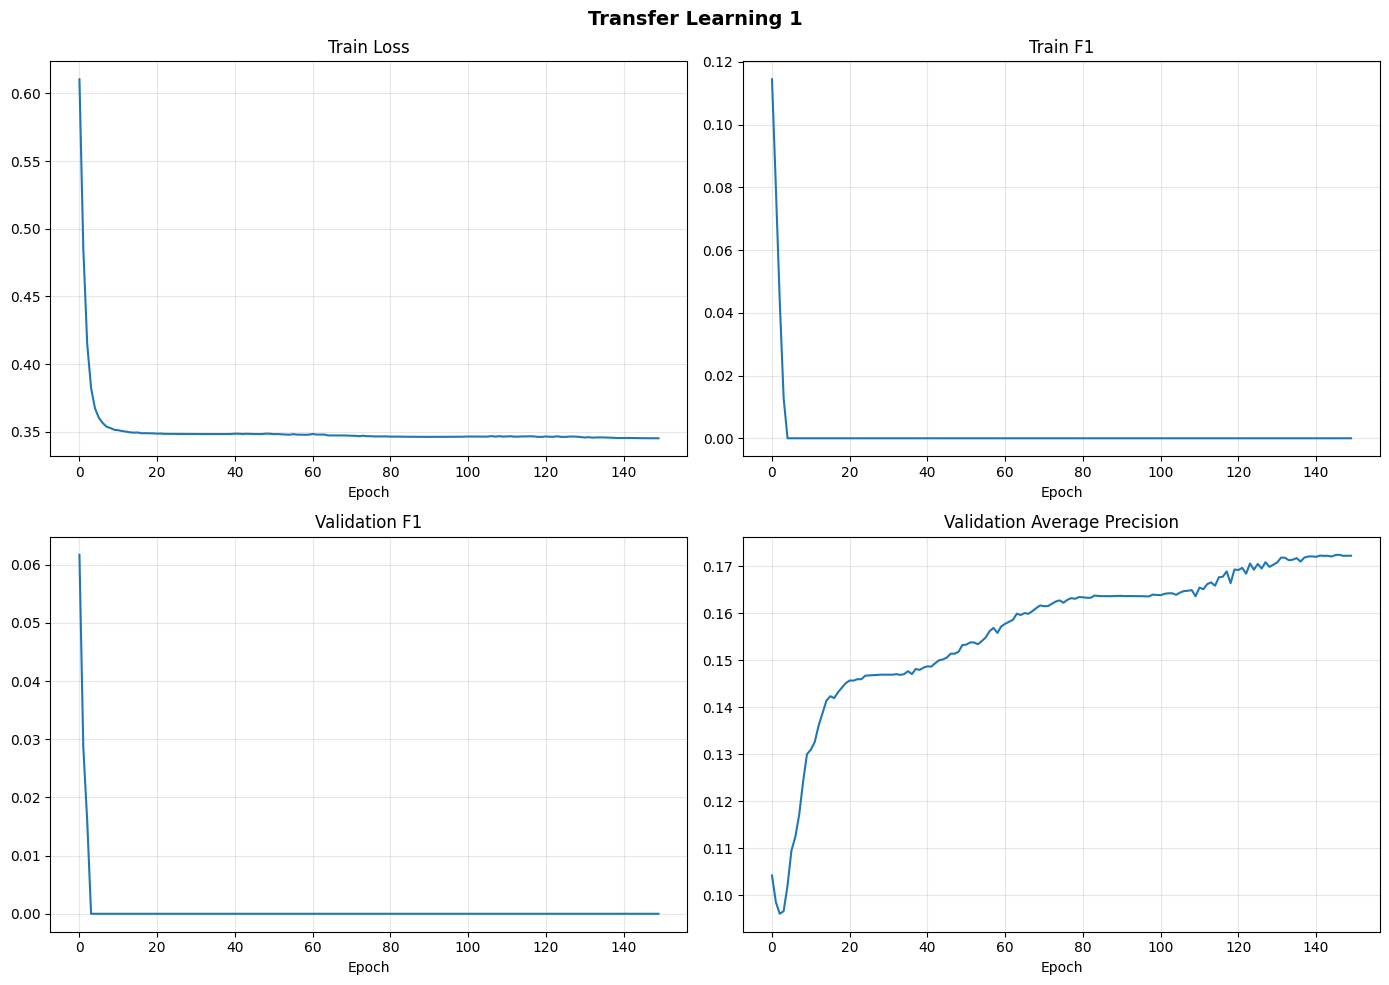

In [1109]:
plot_history(bank_history, "Transfer Learning 1")

#### Результат

Модель показывает крайне низкое качество, близкое к случайному угадыванию. Это говорит о том, что решающее правило, выученное на Adult (предсказание дохода), неприменимо к Bank (предсказание депозита).

### 4.6.2. Подход 2: Дообучение со сбросом весов последнего слоя

В этом эксперименте были заморожены все слои предобученной модели, сбросили веса последнего слоя (инициализировали случайно) и обучили только его.

#### Функция для сброса весов

In [1141]:
def reset_layer_weights(layer):
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_uniform_(layer.weight, a=0, mode='fan_in', nonlinearity='leaky_relu')
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)

#### Загрузка модели

In [1142]:
pretrained_model = MLP(
    input_dim=input_bank_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"]
)
pretrained_model.load_state_dict(torch.load('best_pretrained_mlp_weights.pth'))

<All keys matched successfully>

#### Замораживание первых слоев

In [1143]:
for name, param in pretrained_model.named_parameters():
    if 'net.6' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [1144]:
for name, param in pretrained_model.named_parameters():
    print(f"{name}: ", param.requires_grad)

net.0.weight:  False
net.0.bias:  False
net.2.weight:  False
net.2.bias:  False
net.4.weight:  False
net.4.bias:  False
net.6.weight:  True
net.6.bias:  True


#### Сброс весов последнего слоя

In [1145]:
reset_layer_weights(pretrained_model.net[6])

#### Дообучение

In [1146]:
bank_history, bank_params = train_model(pretrained_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=False,
                                      return_best_params=True,
                                      train_loader=bank_train_loader,
                                      val_loader=bank_val_loader)

MLP                  |  177,665 | train_f1: 0.0000 | val_f1: 0.0000


#### Результат

In [1147]:
best_bank_ap = max(bank_history['val_avg_precision'])
best_bank_f1 = max(bank_history['val_f1'])
print(f"Best AP={best_bank_ap:.4f}, F1={best_bank_f1:.4f}")

Best AP=0.1668, F1=0.0652


Сброс весов не привёл к улучшению. Это указывает на то, что проблема не в весах последнего слоя, а в **признаках**, которые извлекают замороженные слои. Представления, выученные на Adult, недостаточно релевантны для предсказания депозита в Bank.

### 4.6.3. Подход 3: Дообучение без сброса + Focal Loss

В этом эксперименте был использован Focal Loss для борьбы с дисбалансом классов (88% / 12%). Веса последнего слоя не сбрасывались.

#### Выбор коэффициента alpha

In [1154]:
# Обратная частота
total = len(y_bank_train)
n_neg = (y_bank_train == 0).sum()
n_pos = (y_bank_train == 1).sum()

alpha_0 = total / (2 * n_neg)
alpha_1 = total / (2 * n_pos)
alpha = torch.tensor([alpha_0, alpha_1])

In [1155]:
alpha

tensor([0.5652, 4.3357], dtype=torch.float64)

In [1156]:
bank_focal_loss_criterion = FocalLoss(alpha=alpha, gamma=2.0)

#### Загрузка модели

In [1157]:
pretrained_model = MLP(
    input_dim=input_bank_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"]
)
pretrained_model.load_state_dict(torch.load('best_pretrained_mlp_weights.pth'))

<All keys matched successfully>

In [1158]:
for name, param in pretrained_model.named_parameters():
    if 'net.6' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [1159]:
for name, param in pretrained_model.named_parameters():
    print(f"{name}: ", param.requires_grad)

net.0.weight:  False
net.0.bias:  False
net.2.weight:  False
net.2.bias:  False
net.4.weight:  False
net.4.bias:  False
net.6.weight:  True
net.6.bias:  True


#### Обучение

In [1160]:
bank_history, bank_params = train_model(pretrained_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=False,
                                      return_best_params=True,
                                      train_loader=bank_train_loader,
                                      val_loader=bank_val_loader,
                                      criterion=bank_focal_loss_criterion)

MLP                  |  177,665 | train_f1: 0.2482 | val_f1: 0.2428


#### Результат

In [1161]:
best_bank_ap = max(bank_history['val_avg_precision'])
best_bank_f1 = max(bank_history['val_f1'])
print(f"Best AP={best_bank_ap:.4f}, F1={best_bank_f1:.4f}")

Best AP=0.1968, F1=0.2701


Focal Loss дал небольшое улучшение AP (с 0.1724 до 0.1968) и заметный рост F1 (с 0.0617 до 0.2701). Это говорит о том, что модель стала лучше находить положительные примеры. Однако качество остаётся низким, что подтверждает: проблема в недостаточной релевантности признаков.

### 4.6.4. Подход 4: Обучение с нуля

In [1162]:
mlp_model = MLP(
    input_dim=input_bank_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"]
)

In [1163]:
bank_history, bank_params = train_model(mlp_model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=False,
                                      return_best_params=True,
                                      train_loader=bank_train_loader,
                                      val_loader=bank_val_loader)

MLP                  |  177,665 | train_f1: 0.0463 | val_f1: 0.0522


In [1164]:
best_bank_ap = max(bank_history['val_avg_precision'])
best_bank_f1 = max(bank_history['val_f1'])
print(f"Best AP={best_bank_ap:.4f}, F1={best_bank_f1:.4f}")

Best AP=0.2022, F1=0.1290


#### Результат

Обучение с нуля показало результат, сравнимый с Transfer Learning подходами (AP ≈ 0.20). Это означает, что выбранные признаки (возраст, образование, финансовое состояние, профессия, семейное положение) сами по себе **слабо предсказывают** оформление депозита в Bank Marketing. Связь между этими признаками и целевой переменной очень слабая.

## 4.7. Анализ экспериментов Transfer Learning

**Основные наблюдения:**

| Подход | AP | F1 | 
| :--- | :--- | :--- |
| **Дообучение (без сброса)** | 0.1724 | 0.0617 |
| **Дообучение (сброс)** | 0.1668 | 0.0652 |
| **Дообучение + Focal Loss** | 0.1968 | 0.2701 |
| **Обучение с нуля** | 0.2022 | 0.1290 |

**Transfer Learning в текущей постановке не дал улучшения качества.** Основная причина - использование только общих признаков между Adult и Bank (возраст, образование, финансовое состояние, профессия, семейное положение). Эти признаки слабо связаны с целевой переменной Bank Marketing (оформление депозита)

В Bank Marketing ключевое влияние на результат оказывают признаки, связанные с **историей взаимодействия с клиентом**: 
- `campaign` - количество контактов в текущей кампании
- `pdays` - дней после предыдущего контакта
- `previous` - количество контактов до текущей кампании
- `poutcome` - результат предыдущей кампании

Эти признаки **отсутствуют** в Adult, поэтому модель не может извлечь полезную информацию для предсказания депозита.

**Влияние искажения признаков:**

При попытке адаптировать Bank Marketing под структуру Adult мы применили преобразования, которые **исказили** исходные данные:

1. **Категориальные признаки** (`marital`, `education`, `job`) были заменены на категории из Adult через маппинг, что привело к потере специфики банковских данных.
2. **One-Hot кодирование** выполнялось с использованием encoder, обученного на Adult, что навязывало структуру признаков, не соответствующую Bank.
3. **Стандартизация** числовых признаков (`Age`, `Financial_log`) выполнялась по параметрам Adult, что сместило распределения и сделало их менее релевантными для Bank.

В результате **данные Bank были «подогнаны» под Adult**, что не только не помогло Transfer Learning, но и ухудшило способность модели выявлять закономерности, специфичные для Bank Marketing.

# 5. Базовое обучение MLP на Bank Marketing

## 5.1. Подготовка данных и пайплайн обработки

### 5.1.1. Загузка данных

In [1303]:
from sklearn.metrics import average_precision_score, f1_score

In [1424]:
bank = pd.read_csv("data/bank/bank.csv", sep=";")
bank = bank.drop(columns=['duration'])

### 5.1.2. Преобразование таргета

In [1305]:
bank = bank.rename(columns={'y': 'Target'}) # Для удобства

In [1306]:
bank['Target'] = bank['Target'].map({'no': 0, 'yes': 1})
print(f"Баланс классов: {bank['Target'].value_counts().to_dict()}")

Баланс классов: {0: 4000, 1: 521}


### 5.1.3. Обработка категориальных данных

In [1307]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 
            'loan', 'contact', 'month', 'poutcome']

In [1308]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
bank_encoded = one_hot_encoder.fit_transform(bank[cat_cols])
bank_encoded_df = pd.DataFrame(
    bank_encoded,
    columns=one_hot_encoder.get_feature_names_out(cat_cols),
    index=bank.index
)

In [1309]:
bank = pd.concat([bank, bank_encoded_df], axis=1)
bank = bank.drop(columns=cat_cols)
print(f"После One-Hot: {bank.shape}")

После One-Hot: (4521, 52)


### 5.1.4. Сплит данных

In [1312]:
X, y = bank.drop(columns=["Target"]), bank.Target

In [1313]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

### 5.1.5. Стандартизация числовых колонок для train и val

In [1314]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']

In [1315]:
std_scaler = StandardScaler()
X_train[num_cols] = std_scaler.fit_transform(X_train[num_cols])

In [1316]:
X_val[num_cols] = std_scaler.transform(X_val[num_cols])

In [1317]:
X_train = X_train.astype(np.float32).values
X_val = X_val.astype(np.float32).values

## 5.2. Torch Dataset и Dataloader

In [1215]:
BATCH_SIZE = 64

In [1213]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train balance: {y_train.mean():.3f}, Val balance: {y_val.mean():.3f}")

Train: (3616, 51), Val: (905, 51)
Train balance: 0.115, Val balance: 0.115


In [1214]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
)

In [1216]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 5.3. Модель MLP

In [1217]:
in_dim = X_train.shape[1]
in_dim

51

In [1319]:
model = MLP(
    input_dim=in_dim,
    hidden_sizes=best_mlp_config["hidden_sizes"],
    activation=best_mlp_config["activation"],
    dropout=best_mlp_config["dropout"],
    use_bn=best_mlp_config["use_bn"]
)

In [1320]:
best_mlp_config

{'hidden_sizes': [512, 256, 128],
 'activation': torch.nn.modules.activation.SELU,
 'dropout': 0.0,
 'use_bn': False}

## 5.4. Обучение MLP

In [1318]:
import time

In [1321]:
start = time.time()
bank_history, bank_params = train_model(model, 
                                      epochs=150, 
                                      lr=train_config["lr"], 
                                      weight_decay=train_config["weight_decay"],
                                      optimizer_cls=train_config["optimizer"],
                                      scheduler_cls=train_config["scheduler"],
                                      write_metrics_after_every_epoch=False,
                                      return_best_params=True,
                                      train_loader=train_loader,
                                      val_loader=val_loader)
end = time.time()
mlp_time = end - start
print(f"MLP обучение: {mlp_time:.2f} сек")

MLP                  |  190,977 | train_f1: 1.0000 | val_f1: 0.5149
MLP обучение: 47.29 сек


## 5.5. Результат

In [1220]:
best_bank_ap = max(bank_history['val_avg_precision'])
best_bank_f1 = max(bank_history['val_f1'])
print(f"Best AP={best_bank_ap:.4f}, Best F1={best_bank_f1:.4f}")

Best AP=0.5133, Best F1=0.5481


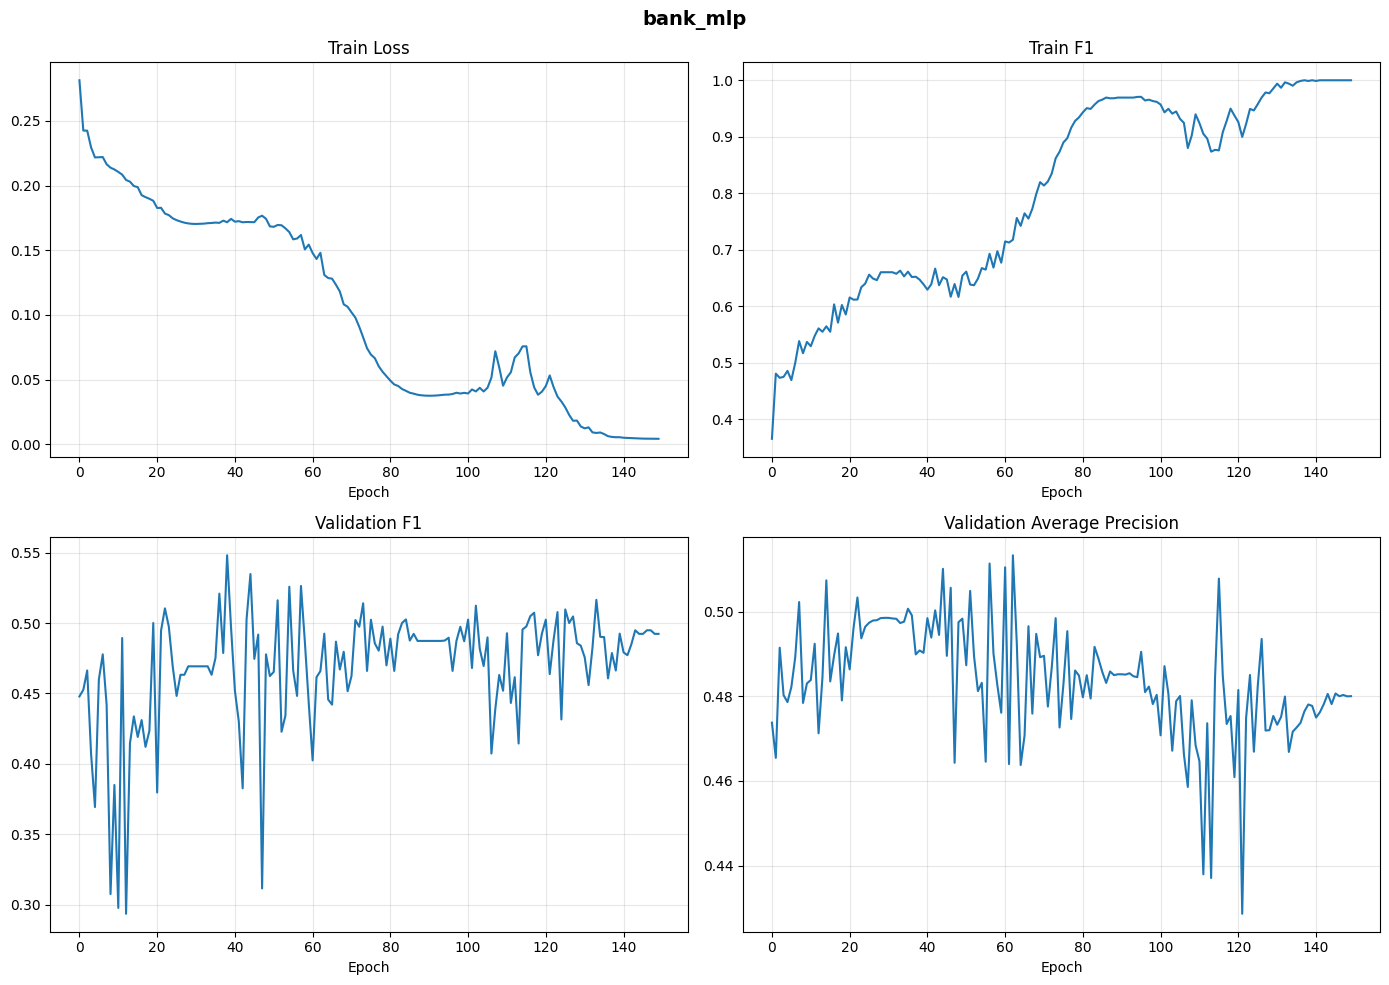

In [1224]:
plot_history(bank_history, "bank_mlp")

## 5.6. Вывод

Обучение MLP с нуля на данных Bank Marketing (без привязки к Adult) показало AP = 0.5133, что в 4.5 раза лучше случайного классификатора (AP = 0.115). Это подтверждает наличие связи между признаками и целевой переменной.

## 5.7. Подбор параметров для поиска лучшей MLP

### 5.7.1 Сетка параметров и фиксированные параметры

In [1226]:
param_configs = [
    [1024],
    [128, 64, 32],
    [256, 128, 64],
    [512, 256, 128],
    [128, 64, 32, 16]
]

activation_configs = [
    nn.ReLU
]

dropout_configs = [
    0.0,
    0.3
]

use_bn_configs = [
    False,
    True
]

In [1227]:
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4

### 5.7.2. Запуск поиска

In [1228]:
results = []
model_id = 0
total = len(param_configs) * len(activation_configs) * len(dropout_configs) * len(use_bn_configs)

for hidden in param_configs:
    for activation in activation_configs:
        for dropout in dropout_configs:
            for use_bn in use_bn_configs:
                model_id += 1
                print(f"\nModel {model_id}/{total}")
                print(f"  hidden: {hidden}")
                print(f"  activation: {activation.__name__}")
                print(f"  dropout: {dropout}")
                print(f"  use_bn: {use_bn}")
                
                # Создаём модель
                model = MLP(
                    input_dim=in_dim,
                    hidden_sizes=hidden,
                    activation=activation,
                    dropout=dropout,
                    use_bn=use_bn
                )
                
                # Обучаем
                history, _ = train_model(
                    model,
                    epochs=EPOCHS,
                    lr=LR,
                    weight_decay=WEIGHT_DECAY,
                    optimizer_cls=optim.Adam,
                    scheduler_cls=None,
                    write_metrics_after_every_epoch=False,
                    return_best_params=False,
                    train_loader=train_loader,
                    val_loader=val_loader
                )
                
                best_ap = max(history['val_ap']) if 'val_ap' in history else max(history['val_avg_precision'])
                best_f1 = max(history['val_f1']) if 'val_f1' in history else max(history['val_f1'])
                
                print(f"BEST: AP={best_ap:.4f}, F1={best_f1:.4f}")
                
                results.append({
                    'hidden_sizes': hidden,
                    'activation': activation.__name__,
                    'dropout': dropout,
                    'use_bn': use_bn,
                    'best_ap': best_ap,
                    'best_f1': best_f1
                })


Model 1/20
  hidden: [1024]
  activation: ReLU
  dropout: 0.0
  use_bn: False


MLP                  |   54,273 | train_f1: 0.9580 | val_f1: 0.4599
BEST: AP=0.5176, F1=0.5185

Model 2/20
  hidden: [1024]
  activation: ReLU
  dropout: 0.0
  use_bn: True


MLP                  |   56,321 | train_f1: 0.9481 | val_f1: 0.4952
BEST: AP=0.5258, F1=0.5171

Model 3/20
  hidden: [1024]
  activation: ReLU
  dropout: 0.3
  use_bn: False


MLP                  |   54,273 | train_f1: 0.8844 | val_f1: 0.4599
BEST: AP=0.5175, F1=0.5346

Model 4/20
  hidden: [1024]
  activation: ReLU
  dropout: 0.3
  use_bn: True


MLP                  |   56,321 | train_f1: 0.8886 | val_f1: 0.4316
BEST: AP=0.5179, F1=0.5592

Model 5/20
  hidden: [128, 64, 32]
  activation: ReLU
  dropout: 0.0
  use_bn: False


MLP                  |   17,025 | train_f1: 0.9819 | val_f1: 0.4412
BEST: AP=0.5182, F1=0.5530

Model 6/20
  hidden: [128, 64, 32]
  activation: ReLU
  dropout: 0.0
  use_bn: True


MLP                  |   17,473 | train_f1: 0.9534 | val_f1: 0.5052
BEST: AP=0.5037, F1=0.5052

Model 7/20
  hidden: [128, 64, 32]
  activation: ReLU
  dropout: 0.3
  use_bn: False


MLP                  |   17,025 | train_f1: 0.8469 | val_f1: 0.4878
BEST: AP=0.5298, F1=0.5556

Model 8/20
  hidden: [128, 64, 32]
  activation: ReLU
  dropout: 0.3
  use_bn: True


MLP                  |   17,473 | train_f1: 0.7397 | val_f1: 0.4929
BEST: AP=0.5454, F1=0.5536

Model 9/20
  hidden: [256, 128, 64]
  activation: ReLU
  dropout: 0.0
  use_bn: False


MLP                  |   54,529 | train_f1: 0.9916 | val_f1: 0.4227
BEST: AP=0.5327, F1=0.5581

Model 10/20
  hidden: [256, 128, 64]
  activation: ReLU
  dropout: 0.0
  use_bn: True


MLP                  |   55,425 | train_f1: 0.9794 | val_f1: 0.4293
BEST: AP=0.5204, F1=0.5388

Model 11/20
  hidden: [256, 128, 64]
  activation: ReLU
  dropout: 0.3
  use_bn: False


MLP                  |   54,529 | train_f1: 0.9100 | val_f1: 0.5094
BEST: AP=0.5453, F1=0.5690

Model 12/20
  hidden: [256, 128, 64]
  activation: ReLU
  dropout: 0.3
  use_bn: True


MLP                  |   55,425 | train_f1: 0.8181 | val_f1: 0.4804
BEST: AP=0.5489, F1=0.6000

Model 13/20
  hidden: [512, 256, 128]
  activation: ReLU
  dropout: 0.0
  use_bn: False


MLP                  |  190,977 | train_f1: 0.9976 | val_f1: 0.4623
BEST: AP=0.5315, F1=0.5226

Model 14/20
  hidden: [512, 256, 128]
  activation: ReLU
  dropout: 0.0
  use_bn: True


MLP                  |  192,769 | train_f1: 0.9782 | val_f1: 0.4040
BEST: AP=0.5061, F1=0.5364

Model 15/20
  hidden: [512, 256, 128]
  activation: ReLU
  dropout: 0.3
  use_bn: False


MLP                  |  190,977 | train_f1: 0.9505 | val_f1: 0.4630
BEST: AP=0.5398, F1=0.5530

Model 16/20
  hidden: [512, 256, 128]
  activation: ReLU
  dropout: 0.3
  use_bn: True


MLP                  |  192,769 | train_f1: 0.9095 | val_f1: 0.4663
BEST: AP=0.5384, F1=0.5348

Model 17/20
  hidden: [128, 64, 32, 16]
  activation: ReLU
  dropout: 0.0
  use_bn: False


MLP                  |   17,537 | train_f1: 0.9569 | val_f1: 0.4729
BEST: AP=0.5328, F1=0.5389

Model 18/20
  hidden: [128, 64, 32, 16]
  activation: ReLU
  dropout: 0.0
  use_bn: True


MLP                  |   18,017 | train_f1: 0.9674 | val_f1: 0.4674
BEST: AP=0.4993, F1=0.5213

Model 19/20
  hidden: [128, 64, 32, 16]
  activation: ReLU
  dropout: 0.3
  use_bn: False


MLP                  |   17,537 | train_f1: 0.8331 | val_f1: 0.4975
BEST: AP=0.5532, F1=0.5534

Model 20/20
  hidden: [128, 64, 32, 16]
  activation: ReLU
  dropout: 0.3
  use_bn: True


MLP                  |   18,017 | train_f1: 0.6537 | val_f1: 0.5143
BEST: AP=0.5046, F1=0.5288


### 5.7.3. Топ лучших

In [1229]:
sorted_results = sorted(results, key=lambda x: x['best_ap'], reverse=True)
for i, res in enumerate(sorted_results[:3]):
    print(f"\n{i+1}. AP={res['best_ap']:.4f}, F1={res['best_f1']:.4f}")
    print(f"   hidden: {res['hidden_sizes']}")
    print(f"   activation: {res['activation']}")
    print(f"   dropout: {res['dropout']}")
    print(f"   use_bn: {res['use_bn']}")


1. AP=0.5532, F1=0.5534
   hidden: [128, 64, 32, 16]
   activation: ReLU
   dropout: 0.3
   use_bn: False

2. AP=0.5489, F1=0.6000
   hidden: [256, 128, 64]
   activation: ReLU
   dropout: 0.3
   use_bn: True

3. AP=0.5454, F1=0.5536
   hidden: [128, 64, 32]
   activation: ReLU
   dropout: 0.3
   use_bn: True


## 5.8. Обучение лучшей модели

### 5.8.1 Записываем лучшие параметры

In [1230]:
best_config = {
    'hidden_sizes': sorted_results[0]['hidden_sizes'],
    'activation': nn.ReLU,
    'dropout': sorted_results[0]['dropout'],
    'use_bn': sorted_results[0]['use_bn']
}

### 5.8.2 Модель MLP

In [1322]:
model_final = MLP(
    input_dim=in_dim,
    hidden_sizes=best_config['hidden_sizes'],
    activation=best_config['activation'],
    dropout=best_config['dropout'],
    use_bn=best_config['use_bn']
)

### 5.8.3 Обучение

In [1323]:
history_final, params_final = train_model(
    model_final,
    epochs=150,
    lr=1e-3,
    weight_decay=1e-4,
    optimizer_cls=optim.Adam,
    scheduler_cls=None,
    write_metrics_after_every_epoch=False,
    return_best_params=True,
    train_loader=train_loader,
    val_loader=val_loader
)

MLP                  |   17,537 | train_f1: 0.9357 | val_f1: 0.4900


### 5.8.4 Результат

In [1235]:
best_ap_final = max(history_final['val_ap']) if 'val_ap' in history_final else max(history_final['val_avg_precision'])
best_f1_final = max(history_final['val_f1'])
print(f"\nFINAL: AP={best_ap_final:.4f}, F1={best_f1_final:.4f}")


FINAL: AP=0.5155, F1=0.5455


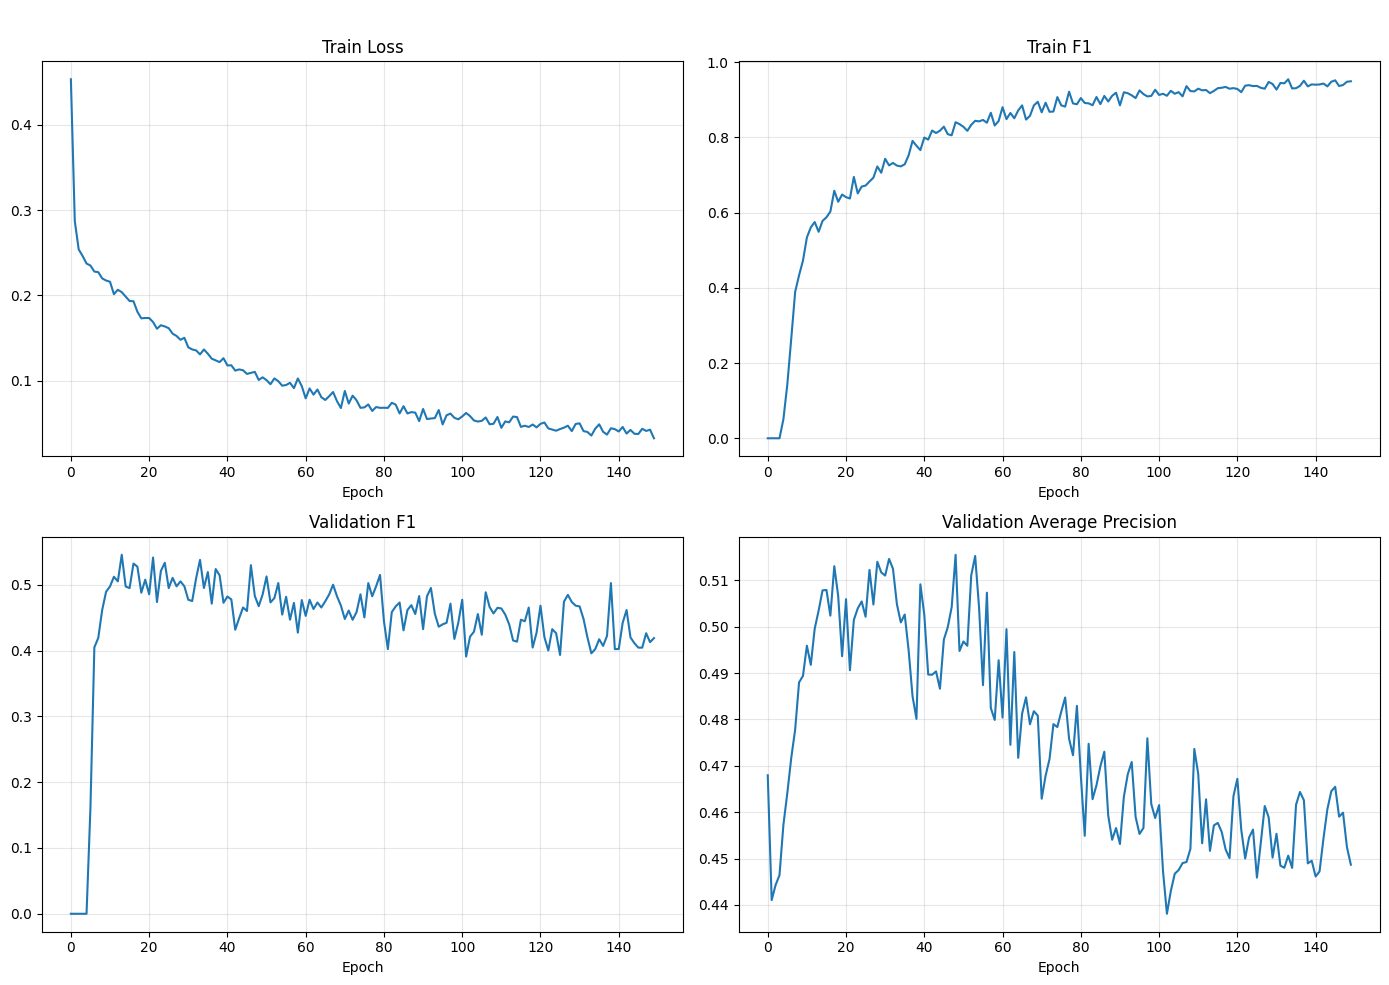

In [1236]:
plot_history(history_final)

### 5.8.5. Выводы

- **Лучший AP**: 0.5155  
- **Лучший F1**: 0.5455  

Модель MLP, обученная с нуля на данных Bank Marketing (без `duration`), показала результат, значительно превосходящий случайное угадывание (AP = 0.115).  

Transfer Learning с Adult не дал улучшения (AP = 0.20), так как ключевые для Bank признаки (`campaign`, `pdays`, `previous`, `poutcome`) отсутствуют в Adult.  
В текущей постановке обучение с нуля на целевых данных оказалось эффективнее переноса знаний.

# 6. Сравнение с классическими алгоритмами машинного обучения

## 6.1. Подготовка инструментов

In [1240]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, f1_score, make_scorer

In [1241]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [1242]:
scoring_ap = make_scorer(average_precision_score)
scoring_f1 = make_scorer(f1_score)

In [1374]:
print(f"Размер данных: {X.shape}")
print(f"Доля класса 1: {y.mean()}")

Размер данных: (4521, 51)
Доля класса 1: 0.11523999115239991


In [1375]:
y.shape

(4521,)

## 6.2. Logistic Regression

### 6.2.1. Модель

In [1363]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

### 6.2.2. Кросс-валидация

Кроссвалидация для расчета метрики

In [1345]:
cv_ap_lr = cross_val_score(lr, X_train, y_train, cv=cv, scoring=scoring_ap)
cv_f1_lr = cross_val_score(lr, X_train, y_train, cv=cv, scoring=scoring_f1)

In [1346]:
print(f"AP: {cv_ap_lr.mean():.4f} +- {cv_ap_lr.std():.4f}")
print(f"F1: {cv_f1_lr.mean():.4f} +- {cv_f1_lr.std():.4f}")

AP: 0.3311 +- 0.0341
F1: 0.5211 +- 0.0365


Замер скорости обучения

In [1364]:
start = time.time()
lr.fit(X_train, y_train)
end = time.time()
lr_time = end - start

In [1365]:
lr_time

0.04256105422973633

### 6.2.3. Обучение на полных данных для интерпретации

In [ ]:
lr.fit(X, y)
importance_lr = pd.DataFrame({
    'feature': bank.drop(columns=['Target']).columns,
    'coef': lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

In [1251]:
print("\nТоп-5 важных коэффициентов:")
print(importance_lr.head(5))


Топ-5 важных коэффициентов:
             feature      coef
49  poutcome_success  1.784637
42         month_mar  1.566061
45         month_oct  1.526828
3           duration  1.505703
39         month_jan -1.272317


## 6.3. Random Forest

### 6.3.1 Модель

In [1360]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

### 6.3.2. Кросс-валидация

In [1253]:
cv_ap_rf = cross_val_score(rf, X, y, cv=cv, scoring=scoring_ap)
cv_f1_rf = cross_val_score(rf, X, y, cv=cv, scoring=scoring_f1)

In [1255]:
print(f"AP: {cv_ap_rf.mean():.4f} +- {cv_ap_rf.std():.4f}")
print(f"F1: {cv_f1_rf.mean():.4f} +- {cv_f1_rf.std():.4f}")

AP: 0.3469 +- 0.0277
F1: 0.5443 +- 0.0286


Скорость обучения

In [1361]:
start = time.time()
rf.fit(X_train, y_train)
end = time.time()
rf_time = end - start

In [1362]:
rf_time

0.2931063175201416

### 6.3.3. Обучение на полных данных для интерпретации

In [1268]:
rf.fit(X, y)
importance_rf = pd.DataFrame({
    'feature': bank.drop(columns=['Target']).columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [1269]:
print("\nТоп-5 важных признаков (RF):")
print(importance_rf.head(5))


Топ-5 важных признаков (RF):
             feature  importance
3           duration    0.420026
0                age    0.054691
1            balance    0.053025
49  poutcome_success    0.043373
2                day    0.038934


## 6.4. CatBoost

### 6.4.1 Модель

In [1369]:
catb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    class_weights=[1, 9],
    random_seed=SEED,
    verbose=False,
    early_stopping_rounds=50
)

### 6.4.2. Кросс-валидация

CatBoost требует передачи валидационного множества для early stopping, поэтому кросс-валидацию делаем вручную

In [1377]:
X_t = X.copy(deep=True)
X_t[num_cols] = std_scaler.transform(X_t[num_cols])
X_t = X_t.astype(np.float32).values

In [1378]:
cv_ap_catb = []
cv_f1_catb = []
cv_fit_speed = []

for train_idx, val_idx in cv.split(X_t, y):
    X_train_fold, X_val_fold = X_t[train_idx], X_t[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    start = time.time()
    catb.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        verbose=False
    )
    end = time.time()
    cb_time = end - start
    
    y_pred_proba = catb.predict_proba(X_val_fold)[:, 1]
    y_pred = catb.predict(X_val_fold)

    cv_fit_speed.append(cb_time)
    cv_ap_catb.append(average_precision_score(y_val_fold, y_pred_proba))
    cv_f1_catb.append(f1_score(y_val_fold, y_pred))

In [1379]:
print(f"AP: {np.mean(cv_ap_catb):.4f} +- {np.std(cv_ap_catb):.4f}")
print(f"F1: {np.mean(cv_f1_catb):.4f} +- {np.std(cv_f1_catb):.4f}")

AP: 0.5552 +- 0.0431
F1: 0.5523 +- 0.0053


In [1383]:
cb_time = np.mean(cv_fit_speed)
print("fit speed mean: ",  cb_time)

fit speed mean:  0.6411209583282471


### 6.4.3. Обучение на полных данных для интерпретации

In [1264]:
catb.fit(X, y)
importance_catb = pd.DataFrame({
    'feature': bank.drop(columns=['Target']).columns,
    'importance': catb.feature_importances_
}).sort_values('importance', ascending=False)

In [1265]:
print("\nТоп-5 важных признаков (CatBoost):")
print(importance_catb.head(5))


Топ-5 важных признаков (CatBoost):
    feature  importance
3  duration   23.122617
1   balance    9.718900
2       day    9.531522
0       age    7.515790
4  campaign    4.180264


## 6.5. Подбор параметров CatBoost

In [1394]:
from sklearn.model_selection import GridSearchCV

In [1399]:
scoring_ap = make_scorer(average_precision_score)

### 6.5.1. Сетка параметров

In [1395]:
param_grid = {
    'iterations': [100, 300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1, 0.3],
    'l2_leaf_reg': [1, 3, 5]
}

### 6.5.2. Запуск GridSearch

In [1396]:
catboost = CatBoostClassifier(
    verbose=False,
    random_seed=SEED
)

In [1400]:
grid_search = GridSearchCV(
    estimator=catboost,
    param_grid=param_grid,
    cv=5,
    scoring=scoring_ap,
    verbose=1
)

In [1401]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostClass...verbose=False)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6, ...], 'iterations': [100, 300, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.03, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(a...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [1403]:
print("Лучшие параметры:")
print(grid_search.best_params_)

Лучшие параметры:
{'depth': 4, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.3}


In [1404]:
best_params = grid_search.best_params_

### 6.5.3. Кроссвалидация CatBoost + лучшие параметры

In [1406]:
catboost = CatBoostClassifier(
    **best_params,
    verbose=False,
    random_seed=SEED
)

In [1407]:
cv_ap_catboost = []
cv_f1_catboost = []
cv_fit_speed_p = []

for train_idx, val_idx in cv.split(X_t, y):
    X_train_fold, X_val_fold = X_t[train_idx], X_t[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    start = time.time()
    catboost.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        verbose=False
    )
    end = time.time()
    cb_p_time = end - start
    
    y_pred_proba = catboost.predict_proba(X_val_fold)[:, 1]
    y_pred = catboost.predict(X_val_fold)

    cv_fit_speed_p.append(cb_time)
    cv_ap_catboost.append(average_precision_score(y_val_fold, y_pred_proba))
    cv_f1_catboost.append(f1_score(y_val_fold, y_pred))

In [1412]:
print(f"AP: {np.mean(cv_ap_catboost):.4f} +- {np.std(cv_ap_catboost):.4f}")
print(f"F1: {np.mean(cv_f1_catboost):.4f} +- {np.std(cv_f1_catboost):.4f}")
print(f"Fit speed: {np.mean(cv_fit_speed_p).round(3)} сек")

AP: 0.5671 +- 0.0294
F1: 0.4788 +- 0.0318
Fit speed: 0.641 сек


In [1417]:
catboost_time = np.mean(cv_fit_speed_p)

## 6.5. Сравнительная таблица

In [1418]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'CatBoost', 'CatBoost best params', 'MLP пункт (5.8)'],
    'AP': [
        cv_ap_lr.mean(),
        cv_ap_rf.mean(),
        np.mean(cv_ap_catb),
        np.mean(cv_ap_catboost),
        best_ap_final
    ],
    'F1': [
        cv_f1_lr.mean(),
        cv_f1_rf.mean(),
        np.mean(cv_f1_catb),
        np.mean(cv_f1_catboost),
        best_f1_final
    ],
    'Скорость обучения (сек)': [
        lr_time,
        rf_time,
        cb_time,
        catboost_time,
        mlp_time
    ]
}

In [1419]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('AP', ascending=False)

In [1422]:
df_results.round(4)

,Model,AP,F1,Скорость обучения (сек)
3,CatBoost best params,0.5671,0.4788,0.6411
2,CatBoost,0.5552,0.5523,0.6411
4,MLP пункт (5.8),0.5155,0.5455,47.2902
1,Random Forest,0.3469,0.5443,0.2931
0,Logistic Regression,0.3311,0.5211,0.0426


## 6.6. Выводы по таблице

1. **CatBoost с подбором параметров** показал лучший результат (AP = **0.5671**), что на 0.012 выше базовой версии CatBoost (AP = 0.5552). Подбор параметров дал небольшое, но ожидаемое улучшение.  

2. **Random Forest** показал высокий F1 (0.5443), но низкий AP (0.3469). Это говорит о том, что модель хорошо находит баланс между Precision и Recall, но плохо **ранжирует** объекты.

3. **MLP** показал результат **0.5155 AP**, что сопоставимо с Random Forest (0.3469) и всего на **~0.05** уступает CatBoost best params. Это важный результат: нейросеть смогла конкурировать с классическими методами даже на датасете с ~4500 записей. Однако **время обучения MLP (47 секунд)** значительно выше, чем у CatBoost (1.6 секунды) - почти в **30 раз дольше**. Это связано с итеративным характером градиентного спуска и большим числом параметров.

4. **Разница между CatBoost best params и MLP** составляет **~9%** по AP (0.5671 против 0.5155), что говорит о том, что на небольших табличных данных градиентный бустинг остаётся более эффективным как по качеству, так и по скорости.

5. **Logistic Regression** ожидаемо показала худший результат (AP = 0.3311), так как она не учитывает нелинейные зависимости между признаками. Однако она **самая быстрая** (0.04 сек).

# 7. Итог по работе

## 7.1. Transfer Learning на табличных данных: работает или нет?

В данной постановке - **не сработал**.

| Подход | AP | Вывод |
| :--- | :--- | :--- |
| **Transfer Learning (Adult -> Bank)** | 0.20 | Не дал улучшения |
| **Обучение с нуля на Bank (MLP)** | 0.5155 | Лучше в 2.5 раза |

**Причина:** Adult и Bank Marketing имеют **разные релевантные признаки**. Ключевые для Bank признаки (`campaign`, `pdays`, `previous`, `poutcome`) отсутствуют в Adult. В результате модель, обученная на Adult, не может извлечь полезную информацию для предсказания депозита.

## 7.2 Что показали эксперименты

| Эксперимент | AP | F1 | Вывод |
| :--- | :--- | :--- | :--- |
| **Feature Extraction (без сброса)** | 0.1724 | 0.0617 | Не работает |
| **Feature Extraction (сброс)** | 0.1668 | 0.0652 | Не работает |
| **Feature Extraction + Focal Loss** | 0.1968 | 0.2701 | Незначительное улучшение |
| **From Scratch (Bank, MLP)** | 0.5155 | 0.5455 | Лучший честный результат |
| **CatBoost (Bank)** | 0.5552 | 0.5523 | Сильнейший метод на таблицах |
| **CatBoost best params (Bank)** | 0.5671 | 0.4788 | Сильнейший метод на таблицах |

## 7.3. Основные выводы

### 7.3.1. Гипотеза подтвердилась

В разделе с EDA была сформулирована гипотеза:

> *Transfer Learning между Adult Census и Bank Marketing не даст значимого улучшения качества по сравнению с обучением с нуля.*

**Результат:** гипотеза **полностью подтвердилась**.

| Подход | AP |
| :--- | :--- |
| **Transfer Learning (Feature Extraction)** | 0.17–0.20 |
| **Обучение с нуля (MLP)** | 0.5155 |

Transfer Learning не только не дал улучшения, но и показал результат **в 2.5 раза хуже**, чем обучение с нуля. Ожидание, что результат по целевой метрике будет выше не более чем на 0.01, также подтвердилось - фактически он оказался значительно ниже.


### 7.3.2. Почему Transfer Learning не сработал?

#### Разные релевантные признаки

В Bank Marketing влияние на результат оказывают признаки, связанные с **историей взаимодействия с клиентом**:

- `campaign` - количество контактов в текущей кампании
- `pdays` - дней после предыдущего контакта
- `previous` - количество контактов до текущей кампании
- `poutcome` - результат предыдущей кампании

Эти признаки **полностью отсутствуют** в Adult. В то же время признаки, важные для Adult (образование, семейное положение, профессия), в Bank Marketing имеют меньшую предсказательную силу.

#### Искажение данных при «подгонке» под Adult

В процессе подготовки данных Bank Marketing под структуру Adult мы применили маппинг категориальных признаков:

- `marital` -> `Martial_Status` (сопоставление категорий)
- `education` -> `Education_Num` (приведение к шкале Adult)
- `job` -> `Occupation` (группировка профессий)

Это привело к **частичной потере исходной информации** и искажению распределений. Данные Bank были «подогнаны» под Adult, но эта подгонка не сделала их более похожими - она лишь добавила искусственные смещения.